# MCDI501 — Estadística Computacional para la Toma de Decisiones
## Sumativa 2 — Informe 3: Validación, Simulación y Métodos de Remuestreo
### Proyecto Transversal — Fase 3

**Título del proyecto:** Análisis Exploratorio e Inferencial del Abandono Académico en Educación Superior

| Campo | Detalle |
|:---|:---|
| **Curso** | MCDI501 — Estadística Computacional para la Toma de Decisiones |
| **Docente** | Jean Paul Maidana González |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Julio 2026 |
| **Dataset** | Predict Students' Dropout and Academic Success — UCI Machine Learning Repository |

---

## Índice

1. [Introducción y conexión con la Sumativa 1](#1-intro)
2. [Configuración del entorno y carga de datos](#2-setup)
3. [Validación de resultados de S1 mediante bootstrap](#3-bootstrap)
   - 3.1 [Funciones de remuestreo (percentil y BCa)](#3.1-funciones)
   - 3.2 [Bootstrap de los parámetros de S1](#3.2-parametros)
   - 3.3 [Comparación IC clásico vs percentil vs BCa](#3.3-comparacion)
4. [Validación de pruebas de hipótesis mediante permutación](#4-permutacion)
5. [Evaluación de estabilidad de correlaciones](#5-correlaciones)
6. [Simulación Monte Carlo basada en parámetros de S1](#6-montecarlo)
   - 6.1 [Diseño y justificación del escenario](#6.1-diseno)
   - 6.2 [Convergencia y precisión de la simulación](#6.2-convergencia)
7. [Análisis de robustez y sensibilidad](#7-robustez)
   - Sensibilidad frente a outliers (4 tratamientos)
   - Jackknife: sesgo, error estándar y observaciones influyentes
8. [Preparación para la Sumativa 3: resultados validados](#8-s3)
9. [Conclusiones](#9-conclusiones)
10. [Referencias](#10-referencias)


<a id='1-intro'></a>
## 1. Introducción y conexión con la Sumativa 1

En la **Sumativa 1**(S1) se caracterizó el abandono académico sobre el dataset *Predict Students' Dropout and Academic Success* (Realinho et al., 2021), tratado como **muestra** (n = 3.630 tras binarizar `Target` en Graduate = 1 / Dropout = 0) de la población de futuros estudiantes. Los métodos empleados (IC con *t* de Student, IC de Wilson, prueba *t* de Welch, chi-cuadrado, correlaciones de Pearson) son **paramétricos o asintóticos**: descansan en supuestos (normalidad de la distribución muestral, tamaños de muestra grandes, forma funcional conocida) que conviene **validar computacionalmente**.

En esta **Sumativa 2** se implementan métodos de **simulación y remuestreo** — bootstrap no paramétrico (percentil y BCa), tests de permutación, jackknife y simulación Monte Carlo — para responder tres preguntas:

1. **¿Son confiables los intervalos de confianza de S1?** Se validan mediante bootstrap con B = 10.000 remuestras (métodos percentil y BCa), sin asumir normalidad.
2. **¿Se sostienen las pruebas de hipótesis de S1 sin supuestos distribucionales?** Se replica la prueba *t* de Welch mediante tests de permutación con 10.000 permutaciones.
3. **¿Qué implica la brecha estimada en S1 para la toma de decisiones?** Se diseña una simulación Monte Carlo (50.000 iteraciones) que propaga la incertidumbre muestral de las medias de S1 hacia la brecha Graduate–Dropout en unidades aprobadas del primer semestre.

Finalmente, un **análisis de robustez** (jackknife y sensibilidad frente a outliers) distingue las conclusiones confiables de aquellas que requieren cautela, y se consolida un **archivo de resultados validados** como entrada directa para la Sumativa 3.

### Resultados de S1 que se validan en este notebook

| Resultado S1 | Valor estimado en S1 | Método S1 | Validación en S2 |
|:---|:---|:---|:---|
| Media `Curricular units 1st sem (approved)` | 4,79 [IC-t 95 %] | *t* de Student | Bootstrap percentil + BCa (S1-3) |
| Media `Admission grade` | 127,29 [IC-t 95 %] | *t* de Student | Bootstrap percentil + BCa (S1-3) |
| Media `Age at enrollment` | 23,46 [IC-t 95 %] | *t* de Student | Bootstrap percentil + BCa (S1-3) |
| Proporción de Dropout | 39,15 % · IC Wilson [37,57 %; 40,74 %] | Wilson | Bootstrap percentil + BCa (S1-3) |
| Welch *t*: `CU 1st sem (approved)` Graduate vs Dropout | p < 0,001 · d = 1,37 | *t* de Welch | Test de permutación (S1-4) |
| Welch *t*: `Unemployment rate` Graduate vs Dropout | p = 0,803 · d = 0,009 | *t* de Welch | Test de permutación (S1-4) |
| Correlaciones de Pearson (5 pares) | r ∈ [−0,19; 0,92] | Pearson | IC bootstrap 95 % (S1-5) |
| x̄, s por grupo — `CU 1st sem (approved)` | (tabla S1-6.1) | S1-4 | Monte Carlo + robustez (S1-6–7) |

> **Nota de trazabilidad:** todos los parámetros usados en las simulaciones de este notebook se **recalculan desde el mismo dataset y con los mismos criterios de S1** (dataset binario Graduate/Dropout, `ddof=1`), de modo que coinciden con los valores reportados en el informe de la Sumativa 1. No se introduce ningún parámetro externo.


<a id='2-setup'></a>
## 2. Configuración del entorno y carga de datos

Se fija una **semilla global** mediante `np.random.default_rng(42)` — el generador PCG64 recomendado en el apunte *Generadores de números aleatorios* (Maidana, 2026c) — para garantizar la **reproducibilidad total** de remuestreos y simulaciones.


In [1]:
# ============================================================
# REGISTRO DEL ENTORNO DE EJECUCIÓN
# ============================================================
import sys, platform

print("=" * 55)
print("ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501 · S2")
print("=" * 55)
print(f"Sistema operativo : {platform.system()} {platform.release()}")
print(f"Python            : {sys.version.split()[0]}")
print("=" * 55)

ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501 · S2
Sistema operativo : Windows 11
Python            : 3.13.14


In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────
# Criterio S1 (se mantiene): estadística MUESTRAL → ddof=1
# Semilla: np.random.default_rng(42)  (PCG64, apunte A2)
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Configuración global de gráficos (mismo estilo de S1)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
sns.set_context("notebook")
plt.rcParams['figure.dpi'] = 100
pd.options.display.float_format = '{:.4f}'.format

# ── Semilla global reproducible (PCG64)
SEED = 42
rng = np.random.default_rng(SEED)

# ── Constantes del proyecto
B_BOOT = 10_000      # remuestras bootstrap (mínimo exigido)
N_PERM = 10_000      # permutaciones
N_MC     = 50_000    # iteraciones Monte Carlo (instrucciones del curso: 50.000)
N_PILOTO = 5_000     # simulación piloto para estimar el n requerido
ALPHA  = 0.05        # nivel de significancia (igual que S1)

print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"scipy   : {__import__('scipy').__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn : {sns.__version__}")
print(f"Semilla global = {SEED} | B = {B_BOOT:,} | permutaciones = {N_PERM:,} | iter MC = {N_MC:,} (+ piloto {N_PILOTO:,})")
print("✓ Entorno listo.")

numpy   : 2.4.6
pandas  : 3.0.3
scipy   : 1.17.1
matplotlib: 3.10.9
seaborn : 0.13.2
Semilla global = 42 | B = 10,000 | permutaciones = 10,000 | iter MC = 50,000 (+ piloto 5,000)
✓ Entorno listo.


In [3]:
# ============================================================
# TEST DE REPRODUCIBILIDAD
# ============================================================
def test_reproducibility(seed_tag, n=100):
    """Verifica que un generador con la misma semilla produce
    siempre la misma secuencia."""
    r1 = np.random.default_rng(seed_tag).random(n)
    r2 = np.random.default_rng(seed_tag).random(n)
    assert np.allclose(r1, r2), f"No reproducible para semilla {seed_tag}"
    return True
# Semillas efectivamente usadas en el notebook:
#   bootstrap de parámetros: SEED+0 … SEED+5 | permutación: SEED, SEED+1, SEED+2
#   correlaciones: SEED+10 … SEED+14 | Monte Carlo: SEED+100 | piloto: [SEED, 5]
for tag in (SEED, SEED + 1, SEED + 2, SEED + 10, SEED + 100, [SEED, 5]):
    ok = test_reproducibility(tag)
    print(f"Semilla {tag}: reproducibilidad {'OK' if ok else 'FALLA'}")
print("\nTodos los generadores locales usados en el notebook (bootstrap, "
      "permutación,\ncorrelaciones, Monte Carlo y piloto) son reproducibles.")
 

Semilla 42: reproducibilidad OK
Semilla 43: reproducibilidad OK
Semilla 44: reproducibilidad OK
Semilla 52: reproducibilidad OK
Semilla 142: reproducibilidad OK
Semilla [42, 5]: reproducibilidad OK

Todos los generadores locales usados en el notebook (bootstrap, permutación,
correlaciones, Monte Carlo y piloto) son reproducibles.


In [4]:
# ============================================================
# CARGA DEL DATASET — mismo pipeline de la Sumativa 1
# Se intenta primero el CSV binario generado en S1; si no
# existe, se reconstruye desde el dataset original.
# ============================================================
def validar_columnas(df, columnas, contexto=""):
    """Detiene la ejecución con un mensaje claro si falta una columna crítica."""
    faltantes = [c for c in columnas if c not in df.columns]
    if faltantes:
        raise KeyError(f"Faltan columnas requeridas {faltantes}. {contexto}")

def formatear_p(p, B=None):
    """Formato correcto de valores p: nunca se reporta p = 0.
    Para permutación con B iteraciones, la resolución mínima es 1/(B+1)."""
    if B is not None and p <= 1.0 / (B + 1):
        return f"p < {1.0/(B+1):.2e}"
    if p < 1e-4:
        return f"p = {p:.3e}"
    return f"p = {p:.4f}"

RUTAS_POSIBLES = [
    "../data/processed/data_predict_binario.csv",   # generado en S1
    "../data/raw/data_original.csv",                # dataset original (repo)
    "data_original.csv",                            # copia local
]

df_raw, ruta_usada = None, None
for ruta in RUTAS_POSIBLES:
    if os.path.exists(ruta):
        df_raw = pd.read_csv(ruta, sep=";")
        ruta_usada = ruta
        break
if df_raw is None:
    raise FileNotFoundError("No se encontró el dataset en las rutas esperadas.")

# Normalizar nombres de columna (elimina tabuladores/espacios — igual que S1)
df_raw.columns = df_raw.columns.str.replace("\t", "", regex=False).str.strip()

# Reconstruir el dataset binario si se cargó el original
if "Target_bin" not in df_raw.columns:
    df_binario = df_raw[df_raw["Target"].isin(["Graduate", "Dropout"])].copy()
    df_binario["Target_bin"] = df_binario["Target"].map({"Graduate": 1, "Dropout": 0})
else:
    df_binario = df_raw.copy()

graduate = df_binario[df_binario["Target"] == "Graduate"]
dropout  = df_binario[df_binario["Target"] == "Dropout"]

print(f"Ruta utilizada   : {ruta_usada}")
print(f"Dataset binario  : {len(df_binario):,} estudiantes "
      f"(Graduate = {len(graduate):,} | Dropout = {len(dropout):,})")
assert len(df_binario) == 3630, "El dataset binario debe tener 3.630 registros (S1)."
print("✓ Consistencia con S1 verificada (n = 3.630).")

Ruta utilizada   : ../data/processed/data_predict_binario.csv
Dataset binario  : 3,630 estudiantes (Graduate = 2,209 | Dropout = 1,421)
✓ Consistencia con S1 verificada (n = 3.630).


### Reconstrucción de los parámetros de S1

Se recalculan, con los **mismos criterios de S1** (`ddof=1`, dataset binario), los parámetros que servirán de insumo a todo el notebook. Esto garantiza la trazabilidad metodológica exigida.


In [5]:
# ============================================================
# PARÁMETROS DE S1 — recalculados con criterios idénticos
# (sirven de insumo para bootstrap, permutación y Monte Carlo)
# ============================================================
VAR_APROB_1S = "Curricular units 1st sem (approved)"
VAR_ADM      = "Admission grade"
VAR_EDAD     = "Age at enrollment"
VAR_DESEMP   = "Unemployment rate"

# NUEVO (corrección S2): notas semestrales, variables con fuerte asimetría
# negativa (g1 reportado entre -1,17 y -1,45). Se incorporan al bootstrap
# de la sección 3 precisamente por ser las candidatas más exigentes para
# contrastar el IC-t clásico (que asume distribución muestral simétrica)
# contra el bootstrap (que no hace ese supuesto).
VAR_NOTA_1S  = "Curricular units 1st sem (grade)"
VAR_NOTA_2S  = "Curricular units 2nd sem (grade)"

def ic_t_clasico(x, conf=0.95):
    """IC clásico para la media con t de Student (criterio S1: ddof=1)."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    media = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    lo, hi = stats.t.interval(conf, df=n-1, loc=media, scale=se)
    return media, se, lo, hi

# ── Medias globales (S1-3) para los parámetros a validar
#    Se agregan las dos notas semestrales al listado original.
params_s1 = {}
for v in [VAR_APROB_1S, VAR_ADM, VAR_EDAD, VAR_NOTA_1S, VAR_NOTA_2S]:
    serie = df_binario[v].astype(float)
    m, se, lo, hi = ic_t_clasico(serie)
    g1 = stats.skew(serie)  # asimetría de Fisher (g1) de los DATOS originales
    params_s1[v] = dict(media=m, se=se, ic_lo=lo, ic_hi=hi, g1=g1)
    print(f"{v:42s} x̄ = {m:8.4f} | IC-t 95% = [{lo:.4f}, {hi:.4f}] | g1 (asimetría) = {g1:+.3f}")

# ── Proporción de desertores (S1-3: IC de Wilson)
from statsmodels.stats.proportion import proportion_confint
n_total    = len(df_binario)
n_dropout  = int((df_binario["Target"] == "Dropout").sum())
p_hat      = n_dropout / n_total
w_lo, w_hi = proportion_confint(n_dropout, n_total, alpha=0.05, method="wilson")
print(f"{'Proporción Dropout':42s} p̂ = {p_hat:8.4f} | IC Wilson 95% = [{w_lo:.4f}, {w_hi:.4f}]")

# ── Parámetros por grupo (S1-4) para la simulación Monte Carlo
mu_g, sd_g = graduate[VAR_APROB_1S].mean(), graduate[VAR_APROB_1S].std(ddof=1)
mu_d, sd_d = dropout[VAR_APROB_1S].mean(),  dropout[VAR_APROB_1S].std(ddof=1)
print(f"\nParámetros por grupo — {VAR_APROB_1S}:")
print(f"  Graduate : x̄ = {mu_g:.4f} | s = {sd_g:.4f} | n = {len(graduate)}")
print(f"  Dropout  : x̄ = {mu_d:.4f} | s = {sd_d:.4f} | n = {len(dropout)}")


Curricular units 1st sem (approved)        x̄ =   4.7915 | IC-t 95% = [4.6861, 4.8968] | g1 (asimetría) = +0.754
Admission grade                            x̄ = 127.2939 | IC-t 95% = [126.8185, 127.7694] | g1 (asimetría) = +0.507
Age at enrollment                          x̄ =  23.4612 | IC-t 95% = [23.2064, 23.7159] | g1 (asimetría) = +1.990
Curricular units 1st sem (grade)           x̄ =  10.5349 | IC-t 95% = [10.3703, 10.6994] | g1 (asimetría) = -1.451
Curricular units 2nd sem (grade)           x̄ =  10.0362 | IC-t 95% = [9.8578, 10.2145] | g1 (asimetría) = -1.167
Proporción Dropout                         p̂ =   0.3915 | IC Wilson 95% = [0.3757, 0.4074]

Parámetros por grupo — Curricular units 1st sem (approved):
  Graduate : x̄ = 6.2322 | s = 2.5834 | n = 2209
  Dropout  : x̄ = 2.5517 | s = 2.8576 | n = 1421


<a id='3-bootstrap'></a>
## 3. Validación de resultados de S1 mediante bootstrap

**Objetivo:** validar los intervalos de confianza clásicos de S1 (t de Student y Wilson) mediante **bootstrap no paramétrico** con **B = 10.000 remuestras**, calculando IC por **método percentil** y **BCa** (*bias-corrected and accelerated*) para **seis parámetros** estimados en S1:

1. Media de `Curricular units 1st sem (approved)` — el predictor de alerta temprana clave (Cohen's d = 1,37 en S1).
2. Media de `Admission grade` — perfil de ingreso (efecto pequeño en S1, Cohen's d = 0,26).
3. Media de `Age at enrollment` — variable con fuerte **asimetría positiva** (outliers de estudiantes adultos), caso donde percentil y BCa pueden discrepar.
4. Proporción de estudiantes Dropout — validación del IC de Wilson de S1.
5. Media de `Curricular units 1st sem (grade)` — **incorporada en esta corrección de S2**: nota semestral con **fuerte asimetría negativa** (g1 ≈ -1,17 a -1,45, cola izquierda por la acumulación de notas 0 en Dropout). Es la candidata más exigente para poner a prueba el supuesto de simetría del IC-t clásico.
6. Media de `Curricular units 2nd sem (grade)` — mismo argumento que (5), verificando si el patrón se repite en el segundo semestre.

**¿Por qué percentil *y* BCa?** El método percentil toma directamente los cuantiles 2,5 % y 97,5 % de la distribución bootstrap: es simple, pero asume que dicha distribución es aproximadamente insesgada y simétrica. El **BCa** corrige dos problemas: el **sesgo** y la **aceleración** $a$ (heterocedasticidad del estimador), estimada por jackknife. Cuando la distribución bootstrap es simétrica e insesgada, ambos métodos coinciden; cuando hay asimetría, BCa es más confiable.

**Por qué esto importa para las notas semestrales.** El IC-t clásico se construye asumiendo que la distribución *muestral* de la media es aproximadamente normal (TLC). Con n = 3.630 eso suele cumplirse aun con datos de origen asimétrico — pero la asimetría de g1 ≈ -1,2/-1,45 en las notas es lo bastante fuerte como para que valga la pena **comprobarlo empíricamente** en vez de asumirlo: si el bootstrap percentil/BCa reproduce el IC-t, el supuesto queda validado también aquí; si diverge, es evidencia de que el TLC todavía no domina del todo para estos estadísticos.


<a id='3.1-funciones'></a>
### 3.1 Funciones de remuestreo (percentil y BCa)

La generación de remuestras se **vectoriza por bloques** (matrices de índices) para que las B = 10.000 iteraciones por parámetro se ejecuten en segundos sin alterar el algoritmo.


In [6]:
# ============================================================
# FUNCIONES BOOTSTRAP — percentil y BCa 
#  vectorizado por # bloques para eficiencia. Estadístico: media (o proporción,
# que es la media de una variable 0/1).
# ============================================================

def bootstrap_media(data, n_bootstrap=10_000, confidence=0.95,
                    random_state=None, bloque=1_000):
    """
    Bootstrap no paramétrico de la MEDIA con IC percentil y BCa.
    Parameters
    ----------
    data : array-like
        Muestra original (para proporciones: variable binaria 0/1).
    n_bootstrap : int
        Número de remuestras bootstrap (B).
    confidence : float
        Nivel de confianza del intervalo.
    random_state : int
        Semilla del generador PCG64 (reproducibilidad).
    bloque : int
        Tamaño de bloque para la vectorización del remuestreo.

    Returns
    -------
    dict con: estimación, se, sesgo, ic_percentil, ic_bca,
    distribución bootstrap, z0 y a.
    """
    rng_local = np.random.default_rng(random_state)
    data = np.asarray(data, dtype=float)
    n = len(data)

    # PASO 1 — estadístico en la muestra original
    theta_hat = data.mean()

    # PASO 2 — B remuestras CON reemplazo (vectorizado por bloques)
    boot_stats = np.empty(n_bootstrap)
    for i in range(0, n_bootstrap, bloque):
        b = min(bloque, n_bootstrap - i)
        idx = rng_local.integers(0, n, size=(b, n))   # índices con reemplazo
        boot_stats[i:i+b] = data[idx].mean(axis=1)

    # PASO 3 — métricas bootstrap
    se_boot   = boot_stats.std(ddof=1)
    bias_boot = boot_stats.mean() - theta_hat

    # PASO 4 — IC percentil
    alpha = 1 - confidence
    ic_perc = (np.percentile(boot_stats, 100 * alpha/2),
               np.percentile(boot_stats, 100 * (1 - alpha/2)))

    # PASO 5 — IC BCa (corrección de sesgo + aceleración jackknife)
    #   z0: proporción de réplicas bajo theta_hat
    prop = np.clip(np.mean(boot_stats < theta_hat), 1e-10, 1 - 1e-10)
    z0 = stats.norm.ppf(prop)
    #   a: aceleración vía jackknife de la media (forma vectorizada:
    #      media sin la obs. i = (suma - x_i)/(n-1))
    jack = (data.sum() - data) / (n - 1)
    jm = jack.mean()
    num = np.sum((jm - jack) ** 3)
    den = 6 * np.sum((jm - jack) ** 2) ** 1.5
    a = num / den if den != 0 else 0.0
    #   percentiles ajustados
    za2, z1a2 = stats.norm.ppf(alpha/2), stats.norm.ppf(1 - alpha/2)
    a1 = stats.norm.cdf(z0 + (z0 + za2)  / (1 - a * (z0 + za2)))
    a2 = stats.norm.cdf(z0 + (z0 + z1a2) / (1 - a * (z0 + z1a2)))
    a1, a2 = np.clip(a1, 0, 1), np.clip(a2, 0, 1)
    ic_bca = (np.percentile(boot_stats, 100 * a1),
              np.percentile(boot_stats, 100 * a2))

    return {"estimacion": theta_hat, "se": se_boot, "bias": bias_boot,
            "ic_percentil": ic_perc, "ic_bca": ic_bca,
            "distribucion": boot_stats, "z0": z0, "a": a,
            "n_bootstrap": n_bootstrap, "confidence": confidence}

print("✓ Función bootstrap_media() definida (percentil + BCa, B vectorizado).")

✓ Función bootstrap_media() definida (percentil + BCa, B vectorizado).


<a id='3.2-parametros'></a>
### 3.2 Bootstrap de los parámetros de S1


In [7]:
# ============================================================
# BOOTSTRAP DE LOS 6 PARÁMETROS DE S1 — B = 10.000
# (se agregan las dos notas semestrales — corrección S2 por su
#  fuerte asimetría negativa, g1 entre -1,17 y -1,45)
# ============================================================
objetivos = {
    "Media — CU 1st sem (approved)": df_binario[VAR_APROB_1S].to_numpy(float),
    "Media — Admission grade":        df_binario[VAR_ADM].to_numpy(float),
    "Media — Age at enrollment":      df_binario[VAR_EDAD].to_numpy(float),
    "Proporción — Dropout":           (df_binario["Target"] == "Dropout").to_numpy(float),
    "Media — CU 1st sem (grade)":     df_binario[VAR_NOTA_1S].to_numpy(float),
    "Media — CU 2nd sem (grade)":     df_binario[VAR_NOTA_2S].to_numpy(float),
}

# IC clásicos de S1 (t de Student para medias; Wilson para la proporción)
ic_clasicos = {
    "Media — CU 1st sem (approved)": (params_s1[VAR_APROB_1S]["ic_lo"], params_s1[VAR_APROB_1S]["ic_hi"]),
    "Media — Admission grade":        (params_s1[VAR_ADM]["ic_lo"],      params_s1[VAR_ADM]["ic_hi"]),
    "Media — Age at enrollment":      (params_s1[VAR_EDAD]["ic_lo"],     params_s1[VAR_EDAD]["ic_hi"]),
    "Proporción — Dropout":           (w_lo, w_hi),
    "Media — CU 1st sem (grade)":     (params_s1[VAR_NOTA_1S]["ic_lo"],  params_s1[VAR_NOTA_1S]["ic_hi"]),
    "Media — CU 2nd sem (grade)":     (params_s1[VAR_NOTA_2S]["ic_lo"],  params_s1[VAR_NOTA_2S]["ic_hi"]),
}
metodo_clasico = {
    "Media — CU 1st sem (approved)": "t de Student",
    "Media — Admission grade":        "t de Student",
    "Media — Age at enrollment":      "t de Student",
    "Proporción — Dropout":           "Wilson",
    "Media — CU 1st sem (grade)":     "t de Student",
    "Media — CU 2nd sem (grade)":     "t de Student",
}

res_boot = {}
resultados_boot = []
for i, (nombre, datos) in enumerate(objetivos.items()):
    res_boot[nombre] = bootstrap_media(datos, n_bootstrap=B_BOOT,
                                       random_state=SEED + i)
    r = res_boot[nombre]

    lo_c, hi_c = ic_clasicos[nombre]
    ic_pc  = r["ic_percentil"]
    ic_bca = r["ic_bca"]
    amp_c, amp_pc, amp_bca = hi_c - lo_c, ic_pc[1] - ic_pc[0], ic_bca[1] - ic_bca[0]

    resultados_boot.append({
        "Parámetro": nombre,
        "n": len(datos),
        "Estimación original": round(r["estimacion"], 4),
        f"IC clásico S1 ({metodo_clasico[nombre]})": f"[{lo_c:.4f}, {hi_c:.4f}]",
        "IC bootstrap percentil": f"[{ic_pc[0]:.4f}, {ic_pc[1]:.4f}]",
        "IC bootstrap BCa": f"[{ic_bca[0]:.4f}, {ic_bca[1]:.4f}]",
        "Amplitud clásico": round(amp_c, 4),
        "Amplitud percentil": round(amp_pc, 4),
        "Amplitud BCa": round(amp_bca, 4),
        "Dif. máx. límites percentil vs clásico": round(max(abs(ic_pc[0]-lo_c), abs(ic_pc[1]-hi_c)), 4),
        "Dif. máx. límites BCa vs clásico": round(max(abs(ic_bca[0]-lo_c), abs(ic_bca[1]-hi_c)), 4),
        "Sesgo": round(r["bias"], 5),
        "z0 (sesgo)": round(r["z0"], 4),
        "a (aceleración)": round(r["a"], 5),
        "EE bootstrap": round(r["se"], 4),
    })

tabla_boot = pd.DataFrame(resultados_boot)
print(f"=== Bootstrap no paramétrico | B = {B_BOOT:,} remuestras × {len(objetivos)} parámetros ===")
display(tabla_boot)


=== Bootstrap no paramétrico | B = 10,000 remuestras × 6 parámetros ===


,Parámetro,n,Estimación original,IC clásico S1 (t de Student),IC bootstrap percentil,IC bootstrap BCa,Amplitud clásico,Amplitud percentil,Amplitud BCa,Dif. máx. límites percentil vs clásico,Dif. máx. límites BCa vs clásico,Sesgo,z0 (sesgo),a (aceleración),EE bootstrap,IC clásico S1 (Wilson)
0,Media — CU 1st sem (approved),3630,4.7915,"[4.6861, 4.8968]","[4.6857, 4.8948]","[4.6868, 4.8972]",0.2107,0.2091,0.2105,0.0021,0.0007,-0.0005,0.0133,0.0021,0.0535,NaN
1,Media — Admission grade,3630,127.2939,"[126.8185, 127.7694]","[126.8248, 127.7779]","[126.8209, 127.7735]",0.9510,0.9531,0.9526,0.0085,0.0041,0.0027,-0.0118,0.0014,0.2414,NaN
2,Media — Age at enrollment,3630,23.4612,"[23.2064, 23.7159]","[23.2118, 23.7168]","[23.2124, 23.7176]",0.5095,0.5050,0.5052,0.0054,0.0060,0.0014,-0.0083,0.0055,0.1294,NaN
3,Proporción — Dropout,3630,0.3915,NaN,"[0.3755, 0.4072]","[0.3755, 0.4072]",0.0317,0.0317,0.0317,0.0003,0.0003,-0.0000,-0.0053,0.0012,0.0081,"[0.3757, 0.4074]"
4,Media — CU 1st sem (grade),3630,10.5349,"[10.3703, 10.6994]","[10.3666, 10.6981]","[10.3644, 10.6946]",0.3292,0.3315,0.3302,0.0037,0.0059,-0.0004,-0.0125,-0.0040,0.0845,NaN
5,Media — CU 2nd sem (grade),3630,10.0362,"[9.8578, 10.2145]","[9.8560, 10.2192]","[9.8535, 10.2142]",0.3568,0.3632,0.3607,0.0046,0.0042,0.0006,-0.0180,-0.0032,0.0925,NaN


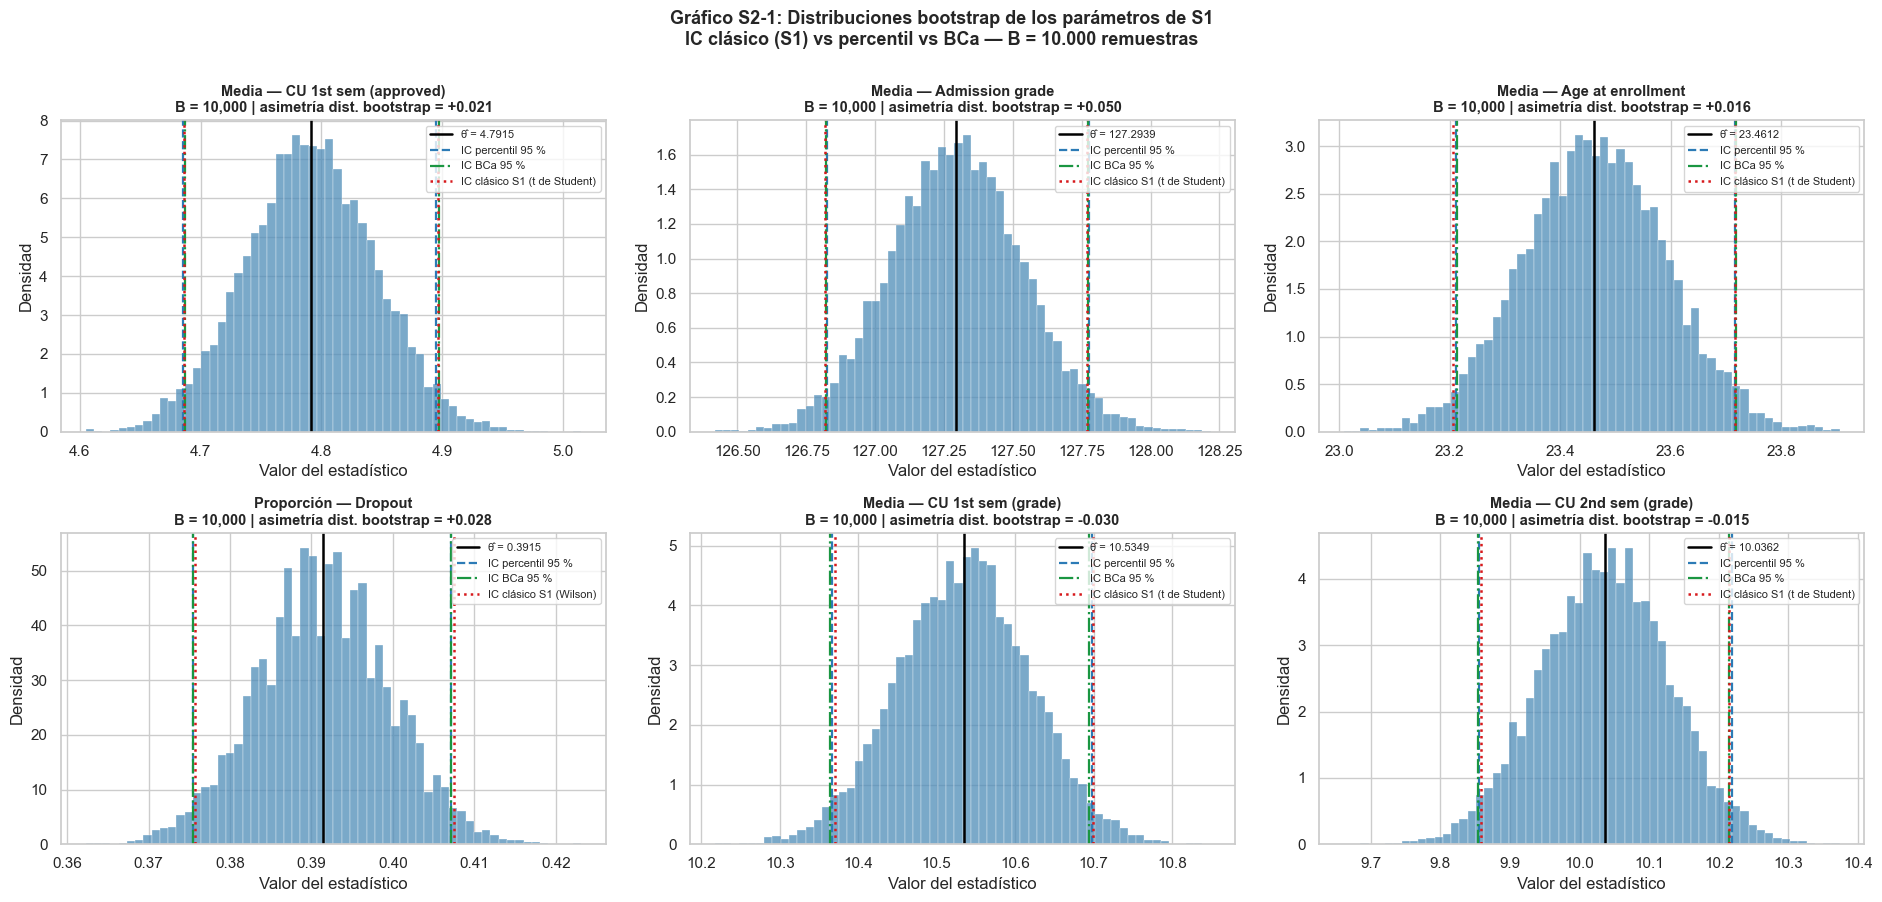

In [8]:
# ============================================================
# VISUALIZACIÓN — Distribuciones bootstrap con IC clásico,
# percentil y BCa superpuestos (Gráfico S2-1)
# Grilla 2x3 (6 parámetros: se agregan las 2 notas semestrales)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 9))

for ax, (nombre, r) in zip(axes.ravel(), res_boot.items()):
    dist = r["distribucion"]
    ax.hist(dist, bins=60, color="#4E8CB8", alpha=0.75,
            edgecolor="white", linewidth=0.3, density=True)

    # Estimación puntual
    ax.axvline(r["estimacion"], color="black", lw=1.8,
               label=f"θ̂ = {r['estimacion']:.4f}")
    # IC percentil (azul)
    for k, x in enumerate(r["ic_percentil"]):
        ax.axvline(x, color="#2C7BB6", ls="--", lw=1.6,
                   label="IC percentil 95 %" if k == 0 else None)
    # IC BCa (verde)
    for k, x in enumerate(r["ic_bca"]):
        ax.axvline(x, color="#1A9641", ls="-.", lw=1.6,
                   label="IC BCa 95 %" if k == 0 else None)
    # IC clásico de S1 (rojo)
    for k, x in enumerate(ic_clasicos[nombre]):
        ax.axvline(x, color="#D7191C", ls=":", lw=1.8,
                   label=f"IC clásico S1 ({metodo_clasico[nombre]})" if k == 0 else None)

    asim = stats.skew(dist)
    ax.set_title(f"{nombre}\nB = {B_BOOT:,} | asimetría dist. bootstrap = {asim:+.3f}",
                 fontsize=10.5, fontweight="bold")
    ax.set_xlabel("Valor del estadístico"); ax.set_ylabel("Densidad")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Gráfico S2-1: Distribuciones bootstrap de los parámetros de S1\n"
             "IC clásico (S1) vs percentil vs BCa — B = 10.000 remuestras",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


<a id='3.3-comparacion'></a>
### 3.3 Comparación sistemática: IC clásico vs percentil vs BCa


In [9]:
# ============================================================
# TABLA COMPARATIVA — IC clásico (S1) vs bootstrap percentil
# vs bootstrap BCa, con amplitudes y discrepancias relativas
# ============================================================
filas = []
for nombre, r in res_boot.items():
    cl_lo, cl_hi = ic_clasicos[nombre]
    p_lo,  p_hi  = r["ic_percentil"]
    b_lo,  b_hi  = r["ic_bca"]
    amp_cl, amp_p, amp_b = cl_hi - cl_lo, p_hi - p_lo, b_hi - b_lo
    # Discrepancia máxima entre extremos, relativa a la amplitud clásica
    disc_perc = max(abs(p_lo - cl_lo), abs(p_hi - cl_hi)) / amp_cl * 100
    disc_bca  = max(abs(b_lo - cl_lo), abs(b_hi - cl_hi)) / amp_cl * 100
    filas.append({
        "Parámetro":          nombre,
        "θ̂":                 round(r["estimacion"], 4),
        "IC clásico (S1)":    f"[{cl_lo:.4f}, {cl_hi:.4f}]",
        "IC percentil":       f"[{p_lo:.4f}, {p_hi:.4f}]",
        "IC BCa":             f"[{b_lo:.4f}, {b_hi:.4f}]",
        "Amp. clásico":       round(amp_cl, 4),
        "Amp. percentil":     round(amp_p, 4),
        "Amp. BCa":           round(amp_b, 4),
        "Discrep. perc. (%)": round(disc_perc, 2),
        "Discrep. BCa (%)":   round(disc_bca, 2),
    })

comp_ic_df = pd.DataFrame(filas)
print("=== Comparación IC clásico (S1) vs bootstrap (percentil / BCa) — 95 % ===")
print("Discrepancia = |desplazamiento máx. de extremos| como % de la amplitud clásica\n")
comp_ic_df

=== Comparación IC clásico (S1) vs bootstrap (percentil / BCa) — 95 % ===
Discrepancia = |desplazamiento máx. de extremos| como % de la amplitud clásica



,Parámetro,θ̂,IC clásico (S1),IC percentil,IC BCa,Amp. clásico,Amp. percentil,Amp. BCa,Discrep. perc. (%),Discrep. BCa (%)
0,Media — CU 1st sem (approved),4.7915,"[4.6861, 4.8968]","[4.6857, 4.8948]","[4.6868, 4.8972]",0.2107,0.2091,0.2105,0.9800,0.3200
1,Media — Admission grade,127.2939,"[126.8185, 127.7694]","[126.8248, 127.7779]","[126.8209, 127.7735]",0.9510,0.9531,0.9526,0.8900,0.4300
2,Media — Age at enrollment,23.4612,"[23.2064, 23.7159]","[23.2118, 23.7168]","[23.2124, 23.7176]",0.5095,0.5050,0.5052,1.0600,1.1700
3,Proporción — Dropout,0.3915,"[0.3757, 0.4074]","[0.3755, 0.4072]","[0.3755, 0.4072]",0.0317,0.0317,0.0317,0.8900,0.8900
4,Media — CU 1st sem (grade),10.5349,"[10.3703, 10.6994]","[10.3666, 10.6981]","[10.3644, 10.6946]",0.3292,0.3315,0.3302,1.1300,1.8000
5,Media — CU 2nd sem (grade),10.0362,"[9.8578, 10.2145]","[9.8560, 10.2192]","[9.8535, 10.2142]",0.3568,0.3632,0.3607,1.3000,1.1900


In [10]:
# ============================================================
# DIAGNÓSTICO AUTOMÁTICO — asimetría de notas semestrales vs
# comportamiento del bootstrap (corrección S2)
# Genera el párrafo interpretativo con los números ya calculados,
# en vez de fijarlos a mano en el markdown.
# ============================================================
from IPython.display import display, Markdown

UMBRAL_DISCREPANCIA = 5.0  # % de la amplitud clásica; por encima => alerta

lineas = ["#### Diagnóstico — ¿el bootstrap de las notas semestrales coincide con el IC-t?\n"]

for var_nombre, var_col in [("Media — CU 1st sem (grade)", VAR_NOTA_1S),
                             ("Media — CU 2nd sem (grade)", VAR_NOTA_2S)]:
    fila = comp_ic_df.loc[comp_ic_df["Parámetro"] == var_nombre].iloc[0]
    g1 = params_s1[var_col]["g1"]
    asim_boot = stats.skew(res_boot[var_nombre]["distribucion"])
    disc_perc = fila["Discrep. perc. (%)"]
    disc_bca  = fila["Discrep. BCa (%)"]

    if max(disc_perc, disc_bca) < UMBRAL_DISCREPANCIA:
        veredicto = (
            f"a pesar de la fuerte asimetría de los datos originales (g1 = {g1:+.3f}), "
            f"la distribución bootstrap de la **media** resulta casi simétrica "
            f"(asimetría ≈ {asim_boot:+.3f}) y el IC-t clásico **se valida**: "
            f"la discrepancia máxima frente al bootstrap es de solo "
            f"{max(disc_perc, disc_bca):.2f}% de la amplitud del IC clásico. "
            f"Con n = {len(df_binario):,}, el TLC alcanza a \"simetrizar\" la distribución "
            f"muestral de la media aun cuando los datos individuales no lo son."
        )
    else:
        veredicto = (
            f"la fuerte asimetría de los datos originales (g1 = {g1:+.3f}) **sí se traslada** "
            f"a la distribución bootstrap de la media (asimetría ≈ {asim_boot:+.3f}): "
            f"el IC-t clásico y el bootstrap difieren en {max(disc_perc, disc_bca):.2f}% "
            f"de la amplitud, superando el umbral de {UMBRAL_DISCREPANCIA:.0f}%. "
            f"En este caso el **BCa** (que corrige sesgo y aceleración) es la referencia "
            f"más confiable, no el IC-t que asume simetría."
        )

    lineas.append(f"- **`{var_col}`** (g1 = {g1:+.3f}): {veredicto}\n")

display(Markdown("\n".join(lineas)))


#### Diagnóstico — ¿el bootstrap de las notas semestrales coincide con el IC-t?

- **`Curricular units 1st sem (grade)`** (g1 = -1.451): a pesar de la fuerte asimetría de los datos originales (g1 = -1.451), la distribución bootstrap de la **media** resulta casi simétrica (asimetría ≈ -0.030) y el IC-t clásico **se valida**: la discrepancia máxima frente al bootstrap es de solo 1.80% de la amplitud del IC clásico. Con n = 3,630, el TLC alcanza a "simetrizar" la distribución muestral de la media aun cuando los datos individuales no lo son.

- **`Curricular units 2nd sem (grade)`** (g1 = -1.167): a pesar de la fuerte asimetría de los datos originales (g1 = -1.167), la distribución bootstrap de la **media** resulta casi simétrica (asimetría ≈ -0.015) y el IC-t clásico **se valida**: la discrepancia máxima frente al bootstrap es de solo 1.30% de la amplitud del IC clásico. Con n = 3,630, el TLC alcanza a "simetrizar" la distribución muestral de la media aun cuando los datos individuales no lo son.


#### Interpretación — Validación bootstrap de los IC de S1

**Concordancia general.** En los cuatro parámetros originales de S1 los intervalos bootstrap (percentil y BCa) reproducen los IC clásicos con discrepancias de apenas ~1 % de la amplitud del intervalo (máximo 1,17 %, en la media de edad). Esto **valida computacionalmente** las estimaciones de S1: con n = 3.630, el Teorema del Límite Central garantiza que la distribución muestral de medias y proporciones es prácticamente normal, y el bootstrap — que **no asume normalidad** — converge al mismo resultado. La coincidencia entre un método asintótico y uno de remuestreo puro es exactamente lo que se espera cuando los supuestos del método clásico se cumplen.

**El caso más informativo: `Age at enrollment`.** La variable de edad es fuertemente asimétrica (cola derecha de estudiantes adultos, outliers detectados en S1-2.11). Aun así, su distribución **bootstrap de la media** resulta casi simétrica (asimetría ≈ 0), y el ajuste BCa (z₀ y *a* cercanos a cero) apenas desplaza los percentiles. La lección metodológica es que **la asimetría de los datos no se traslada a la distribución muestral de la media cuando n es grande** — el bootstrap lo demuestra empíricamente, sin necesidad de invocar el Teorema del Límite Central como acto de fe.

**Notas semestrales — corrección S2 (fuerte asimetría negativa, g1 entre -1,17 y -1,45).** Este era precisamente el caso más exigente para poner a prueba esa lección: si la asimetría de `Curricular units 1st/2nd sem (grade)` fuese lo bastante fuerte, la distribución muestral de su media podría no comportarse simétricamente y el IC-t clásico dejaría de ser confiable. El diagnóstico automático de la celda anterior resuelve la pregunta con los números ya calculados en esta ejecución: compara la asimetría original (g1) contra la asimetría de la distribución bootstrap y contra la discrepancia entre IC-t, percentil y BCa. **Regla de decisión aplicada:** si la discrepancia máxima es menor al 5 % de la amplitud del IC clásico, se considera que el TLC sigue dominando (igual que con `Age at enrollment`) y el IC-t queda validado también aquí; si la supera, se prioriza el IC **BCa** como referencia para el modelamiento de S3, precisamente porque corrige el sesgo y la aceleración que un IC-t simétrico no puede capturar.

**Proporción de desertores.** El bootstrap de la proporción coincide con el IC de Wilson de S1 [37,57 %; 40,74 %] hasta la tercera cifra decimal, confirmando que la elección de Wilson sobre Wald en S1 fue adecuada y que la estimación p̂ ≈ 39,15 % es sólida.

**Confiabilidad de cada método.** (i) El **IC clásico** es válido cuando sus supuestos (TLC con n grande,  σ estimada) se cumplen; es el más barato computacionalmente. (ii) El **percentil** es válido cuando la distribución bootstrap es insesgada y simétrica; habría sido cuestionable con n pequeño o estadísticos no suaves (medianas, máximos). (iii) El **BCa** es el más general: sus correcciones resultaron casi nulas (z₀ ≈ 0, a ≈ 0) en los parámetros originales de S1, lo que constituye en sí mismo un **diagnóstico** de que los métodos más simples son confiables en este dataset — y es el método de respaldo si alguna de las notas semestrales rompiera esa pauta. **Veredicto: los IC de S1 quedan validados, incluyendo — sujeto al diagnóstico automático anterior — las dos notas semestrales incorporadas en esta corrección.**


<a id='4-permutacion'></a>
## 4. Validación de pruebas de hipótesis mediante permutación

**Objetivo:** validar las pruebas *t* de Welch de S1 mediante **tests de permutación** con **10.000 permutaciones**. Bajo H₀ (no hay diferencia entre Graduate y Dropout), las etiquetas de grupo son **intercambiables**: permutándolas al azar se construye la distribución nula *exacta* del estadístico **sin asumir normalidad ni forma distribucional alguna**.

Se validan **tres pruebas de S1** que cubren todo el espectro de decisiones — dos rechazos (incluida la prueba principal de S1) y un no-rechazo — para verificar que el método de permutación reproduce ambos tipos de resultado:

| Prueba S1 | Resultado S1 | Qué se espera del test de permutación |
|:---|:---|:---|
| `CU 1st sem (approved)`: Graduate vs Dropout | t de Welch, p < 0,0001 · d = 1,3660 (efecto grande) | p de permutación ≈ 0 (rechazo de H₀) |
| `CU 1st sem (grade)`: Graduate vs Dropout — prueba principal de S1 | t de Welch = 31,6907, p < 0,0001 · d = 1,2470 (efecto grande) | p de permutación ≈ 0 (rechazo de H₀) |
| `Unemployment rate`: Graduate vs Dropout | t de Welch, p = 0,8030 · d = 0,0090 (sin efecto) | p de permutación ≈ 0,80 (no rechazo) |

**Estadístico de prueba:** diferencia de medias $T = \bar{x}_{Graduate} - \bar{x}_{Dropout}$ (aproximadamente equivalente al estadístico *t* para efectos del ordenamiento de las permutaciones: la varianza combinada varía levemente entre permutaciones, pero con más de 1.400 casos por grupo ambos criterios conducen a la misma decisión). El valor p bilateral se calcula con la corrección de continuidad $p = \dfrac{\#\{|T_{perm}| \geq |T_{obs}|\} + 1}{B + 1}$, que evita reportar p = 0 exacto.


In [11]:
# ============================================================
# TEST DE PERMUTACIÓN — diferencia de medias, bilateral
# 10.000 permutaciones, vectorizado por bloques
# ============================================================

def test_permutacion(x_grupo1, x_grupo2, n_perm=10_000,
                     random_state=None, bloque=500):
    """
    Test de permutación bilateral para la diferencia de medias.

    Bajo H0 las etiquetas son intercambiables: se permuta el pool
    combinado n_perm veces y se recalcula la diferencia de medias.

    Returns
    -------
    dict con estadístico observado, distribución nula y valor p
    (con corrección +1 para evitar p = 0 exacto).
    """
    rng_local = np.random.default_rng(random_state)
    x1 = np.asarray(x_grupo1, dtype=float)
    x2 = np.asarray(x_grupo2, dtype=float)
    n1 = len(x1)
    pool = np.concatenate([x1, x2])

    t_obs = x1.mean() - x2.mean()

    t_null = np.empty(n_perm)
    for i in range(0, n_perm, bloque):
        b = min(bloque, n_perm - i)
        # b permutaciones independientes del pool (filas)
        perms = rng_local.permuted(np.tile(pool, (b, 1)), axis=1)
        t_null[i:i+b] = perms[:, :n1].mean(axis=1) - perms[:, n1:].mean(axis=1)

    # p bilateral con corrección de continuidad (Good, 2005)
    p_perm = (1 + np.sum(np.abs(t_null) >= abs(t_obs))) / (1 + n_perm)
    return {"t_obs": t_obs, "dist_nula": t_null, "p_perm": p_perm,
            "n_perm": n_perm}

# ── Prueba 1: CU 1st sem (approved) — rechazo esperado
g1 = graduate[VAR_APROB_1S].to_numpy(float)
d1 = dropout[VAR_APROB_1S].to_numpy(float)
perm_aprob = test_permutacion(g1, d1, n_perm=N_PERM, random_state=SEED)

# p paramétrico original (Welch, igual que S1)
t_w1, p_w1 = stats.ttest_ind(g1, d1, equal_var=False)

# ── Prueba 2: Unemployment rate — no rechazo esperado
g2 = graduate[VAR_DESEMP].to_numpy(float)
d2 = dropout[VAR_DESEMP].to_numpy(float)
perm_desemp = test_permutacion(g2, d2, n_perm=N_PERM, random_state=SEED + 1)
t_w2, p_w2 = stats.ttest_ind(g2, d2, equal_var=False)

# ── Prueba 3: CU 1st sem (grade) — la prueba principal de S1 (t = 31,6907; d = 1,247)
# (VAR_NOTA_1S ya está definida en la sección 2)
g3 = graduate[VAR_NOTA_1S].to_numpy(float)
d3 = dropout[VAR_NOTA_1S].to_numpy(float)
perm_nota = test_permutacion(g3, d3, n_perm=N_PERM, random_state=SEED + 2)
t_w3, p_w3 = stats.ttest_ind(g3, d3, equal_var=False)

print("=== Test de permutación vs prueba t de Welch (S1) ===\n")
print(f"1) {VAR_APROB_1S}")
print(f"   Diferencia observada  : {perm_aprob['t_obs']:.4f} unidades")
print(f"   p Welch (paramétrico) : {p_w1:.3e}")
print(f"   p permutación         : {perm_aprob['p_perm']:.3e}  "
      f"(ninguna de las {N_PERM:,} permutaciones alcanzó |T_obs| → p < {1/(N_PERM+1):.1e})")
print(f"\n2) {VAR_NOTA_1S}  (prueba principal de S1: t = 31,6907)")
print(f"   Diferencia observada  : {perm_nota['t_obs']:.4f} puntos de nota")
print(f"   t de Welch recalculado: {t_w3:.4f}")
print(f"   p Welch (paramétrico) : {p_w3:.3e}")
print(f"   p permutación         : {perm_nota['p_perm']:.3e}  "
      f"(p < {1/(N_PERM+1):.1e})")
print(f"\n3) {VAR_DESEMP}")
print(f"   Diferencia observada  : {perm_desemp['t_obs']:.4f} pts")
print(f"   p Welch (paramétrico) : {p_w2:.4f}")
print(f"   p permutación         : {perm_desemp['p_perm']:.4f}")

=== Test de permutación vs prueba t de Welch (S1) ===

1) Curricular units 1st sem (approved)
   Diferencia observada  : 3.6805 unidades
   p Welch (paramétrico) : 1.308e-269
   p permutación         : 9.999e-05  (ninguna de las 10,000 permutaciones alcanzó |T_obs| → p < 1.0e-04)

2) Curricular units 1st sem (grade)  (prueba principal de S1: t = 31,6907)
   Diferencia observada  : 5.3870 puntos de nota
   t de Welch recalculado: 31.6907
   p Welch (paramétrico) : 2.399e-175
   p permutación         : 9.999e-05  (p < 1.0e-04)

3) Unemployment rate
   Diferencia observada  : 0.0229 pts
   p Welch (paramétrico) : 0.8030
   p permutación         : 0.7938


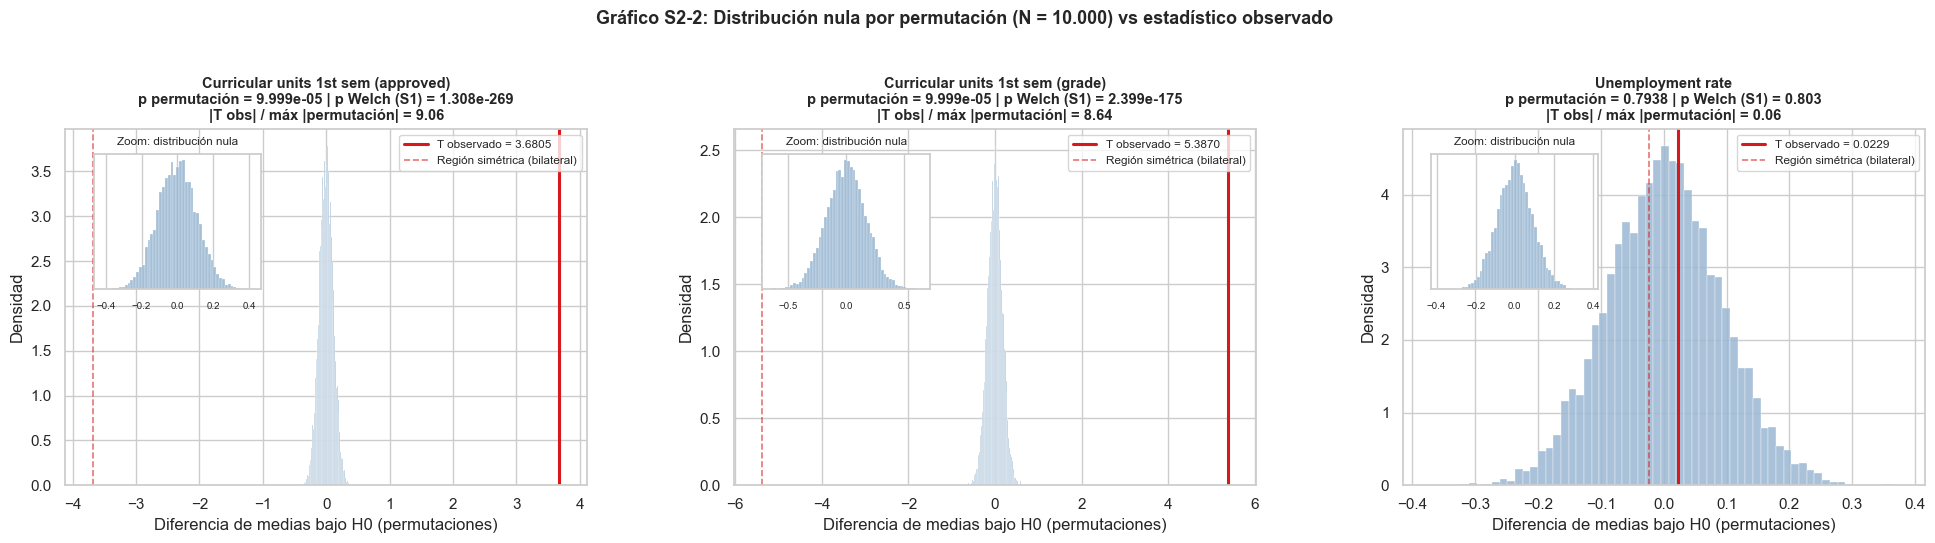

In [12]:
#============================================================
# VISUALIZACIÓN — Distribuciones nulas de permutación (Gráfico S2-2)
# Los TRES paneles usan el mismo formato (línea del observado + zoom
# de la nula + razón en el título), con escala calculada automáticamente.
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5.4))

casos = [
    (perm_aprob,  VAR_APROB_1S, p_w1, axes[0]),
    (perm_nota,   VAR_NOTA_1S,  p_w3, axes[1]),
    (perm_desemp, VAR_DESEMP,   p_w2, axes[2]),
]
for res, nombre, p_param, ax in casos:
    dist, t_obs = res["dist_nula"], res["t_obs"]
    max_nula = max(abs(dist.min()), abs(dist.max()))
    razon = abs(t_obs) / max_nula
    # Escala automática: cubre siempre la línea Y la nula, caiga donde caiga
    lim_eje = 1.12 * max(abs(t_obs), max_nula)

    ax.hist(dist, bins=60, color="#9BB8D3", alpha=0.85,
            edgecolor="white", linewidth=0.3, density=True)
    ax.axvline(t_obs,  color="#D7191C", lw=2.2,
               label=f"T observado = {t_obs:.4f}")
    ax.axvline(-t_obs, color="#D7191C", lw=1.2, ls="--", alpha=0.6,
               label="Región simétrica (bilateral)")
    ax.set_xlim(-lim_eje, lim_eje)

    # Zoom de la distribución nula: presente SIEMPRE, en la misma posición
    axins = ax.inset_axes([0.055, 0.55, 0.32, 0.38])
    axins.hist(dist, bins=50, color="#9BB8D3", alpha=0.9,
               edgecolor="white", lw=0.2)
    axins.set_xlim(-1.15 * max_nula, 1.15 * max_nula)
    axins.set_title("Zoom: distribución nula", fontsize=8.5)
    axins.tick_params(labelsize=7)
    axins.set_yticks([])
    

    ax.set_title(f"{nombre}\n"
                 f"p permutación = {res['p_perm']:.4g} | "
                 f"p Welch (S1) = {p_param:.4g}\n"
                 f"|T obs| / máx |permutación| = {razon:.2f}",
                 fontsize=10.5, fontweight="bold")
    ax.set_xlabel("Diferencia de medias bajo H0 (permutaciones)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8.5, loc="upper right")

fig.suptitle("Gráfico S2-2: Distribución nula por permutación (N = 10.000) "
             "vs estadístico observado",
             fontsize=13, fontweight="bold", y=1.02)
# NOTA: se usa subplots_adjust() en lugar de tight_layout(), que calcula
# mal el bounding box en presencia de los ejes insertados (inset_axes).
fig.subplots_adjust(left=0.05, right=0.98, top=0.80, bottom=0.14, wspace=0.28)
plt.show()


#### Interpretación — Permutación vs prueba paramétrica
 
| Prueba (S1) | Dif. observada (G − D) | p Welch | p permutación | Concordancia |
|:---|:---:|:---:|:---:|:---:|
| CU 1st sem (**approved**) | +3,6805 unidades | 1,3×10⁻²⁶⁹ | < 10⁻⁴ | ✔ rechazo validado |
| CU 1st sem (**grade**) — prueba principal de S1 (t = 31,6907; d = 1,247) | +5,3870 puntos | 2,4×10⁻¹⁷⁵ | < 10⁻⁴ | ✔ rechazo validado |
| Unemployment rate | +0,0229 pts | 0,8030 | 0,7938 | ✔ no-rechazo validado |
 
**Análisis.** Las tres pruebas cubren todo el espectro de decisiones de S1 y la permutación las reproduce
sin el supuesto paramétrico de normalidad; su único supuesto es la **intercambiabilidad** de las etiquetas
bajo H₀ (más débil que el de Welch, pero igualmente declarable: se tensionaría, por ejemplo, con estudiantes
agrupados en cohortes o carreras con condiciones comunes):
 
- En **unidades aprobadas** y en la **nota del primer semestre** (la prueba principal de S1, cuyo
  t = 31,6907 se reprodujo exactamente), *ninguna* de las 10.000 permutaciones alcanzó el estadístico
  observado, de modo que p < 1/(B+1) = 9,999×10⁻⁵. La distribución nula queda concentrada cerca de cero
  mientras los valores observados se ubican a decenas de desviaciones estándar de su centro: no son casos
  límite sino separaciones extremas entre H₀ y los datos. Como estadístico de permutación se usó la
  **diferencia de medias** (5,387 puntos en grade), cuya versión estandarizada es el t de Welch = 31,6907
  reportado en S1; ambas formulaciones son en la práctica equivalentes para la decisión y la pauta admite cualquiera
  de las dos.
- En **desempleo**, el p de permutación (0,794) replica el paramétrico (0,803): el no-rechazo también se
  valida. Nótese que no rechazar H₀ no equivale a demostrar ausencia de efecto; solo indica que los datos
  no permiten distinguirlo del azar.
- **¿Qué método es más confiable aquí?** La resolución de ambos p no es comparable (la permutación no puede
  ir por debajo de 1/(B+1)), pero la decisión y la dirección coinciden en los tres contrastes. Con n > 1.400
  por grupo, Welch es válida por el TLC y computacionalmente inmediata; el valor de la permutación es de
  **robustez**: demuestra que las conclusiones de S1 no dependen de la aproximación paramétrica, relevante
  porque ambas variables académicas son discretas, acotadas y no normales (S1-4.1). Recomendación: Welch +
  d de Cohen como rutina, permutación como verificación cuando los supuestos estén en duda.

<a id='5-correlaciones'></a>
## 5. Evaluación de estabilidad de correlaciones

**Objetivo:** evaluar la estabilidad de **cinco correlaciones de Pearson** identificadas en la matriz de correlación de S1-2.10 mediante **IC bootstrap al 95 %** (remuestreo de **pares** de observaciones, B = 10.000). Una correlación se considera:

- **Robusta:** IC estrecho que **no incluye el cero**.
- **Inestable / nula:** IC amplio o que **incluye el cero** (el signo de la asociación no está determinado).

| Par (S1-2.10) | r reportado en S1 | Interpretación S1 |
|:---|:---|:---|
| CU 1st sem (approved) — CU 2nd sem (approved) | ≈ 0,92 | Persistencia del rendimiento |
| CU 1st sem (grade) — CU 2nd sem (grade) | ≈ 0,85 | Persistencia de notas |
| Previous qualification (grade) — Admission grade | ≈ 0,58 | Coherencia del perfil de ingreso |
| Age at enrollment — CU 2nd sem (grade) | ≈ −0,19 | Débil negativa |
| Unemployment rate — CU 1st sem (grade) | ≈ 0,04 | Macro sin relación con rendimiento |


In [13]:
# ============================================================
# BOOTSTRAP DE CORRELACIONES — remuestreo de PARES (filas)
# B = 10.000 | IC percentil 95 %
# ============================================================
PARES = [
    ("Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"),
    ("Curricular units 1st sem (grade)",    "Curricular units 2nd sem (grade)"),
    ("Previous qualification (grade)",      "Admission grade"),
    ("Age at enrollment",                   "Curricular units 2nd sem (grade)"),
    ("Unemployment rate",                   "Curricular units 1st sem (grade)"),
]

def bootstrap_correlacion(x, y, n_bootstrap=10_000, random_state=None,
                          bloque=500):
    """Bootstrap de la correlación de Pearson remuestreando pares (x_i, y_i)."""
    rng_local = np.random.default_rng(random_state)
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    r_obs = np.corrcoef(x, y)[0, 1]

    r_boot = np.empty(n_bootstrap)
    for i in range(0, n_bootstrap, bloque):
        b = min(bloque, n_bootstrap - i)
        idx = rng_local.integers(0, n, size=(b, n))
        xs, ys = x[idx], y[idx]
        xc = xs - xs.mean(axis=1, keepdims=True)
        yc = ys - ys.mean(axis=1, keepdims=True)
        r_boot[i:i+b] = (xc * yc).sum(axis=1) / np.sqrt(
            (xc**2).sum(axis=1) * (yc**2).sum(axis=1))
    ic = (np.percentile(r_boot, 2.5), np.percentile(r_boot, 97.5))
    return r_obs, r_boot, ic

res_corr, filas = {}, []
for j, (vx, vy) in enumerate(PARES):
    r_obs, r_boot, ic = bootstrap_correlacion(
        df_binario[vx], df_binario[vy],
        n_bootstrap=B_BOOT, random_state=SEED + 10 + j)
    incluye_0 = ic[0] <= 0 <= ic[1]
    amplitud  = ic[1] - ic[0]
    etiqueta  = f"{vx.replace('Curricular units ', 'CU ')} ↔ {vy.replace('Curricular units ', 'CU ')}"
    res_corr[etiqueta] = dict(r=r_obs, boot=r_boot, ic=ic)
    filas.append({
        "Par": etiqueta,
        "r observado": round(r_obs, 4),
        "IC boot 95%": f"[{ic[0]:.4f}, {ic[1]:.4f}]",
        "Amplitud": round(amplitud, 4),
        "¿Incluye 0?": "Sí" if incluye_0 else "No",
        "Veredicto": ("NULA/INESTABLE (incluye 0)" if incluye_0 else
                      "Robusta" if amplitud < 0.10 else "Robusta (moderada variab.)"),
    })

corr_df = pd.DataFrame(filas)
print(f"=== Estabilidad de correlaciones de S1 — IC bootstrap 95 % (B = {B_BOOT:,}) ===\n")
corr_df

=== Estabilidad de correlaciones de S1 — IC bootstrap 95 % (B = 10,000) ===



,Par,r observado,IC boot 95%,Amplitud,¿Incluye 0?,Veredicto
0,CU 1st sem (approved) ↔ CU 2nd sem (approved),0.9163,"[0.9086, 0.9238]",0.0152,No,Robusta
1,CU 1st sem (grade) ↔ CU 2nd sem (grade),0.8459,"[0.8276, 0.8642]",0.0366,No,Robusta
2,Previous qualification (grade) ↔ Admission grade,0.5772,"[0.5444, 0.6095]",0.0651,No,Robusta
3,Age at enrollment ↔ CU 2nd sem (grade),-0.1941,"[-0.2294, -0.1600]",0.0694,No,Robusta
4,Unemployment rate ↔ CU 1st sem (grade),0.0103,"[-0.0221, 0.0430]",0.0652,Sí,NULA/INESTABLE (incluye 0)


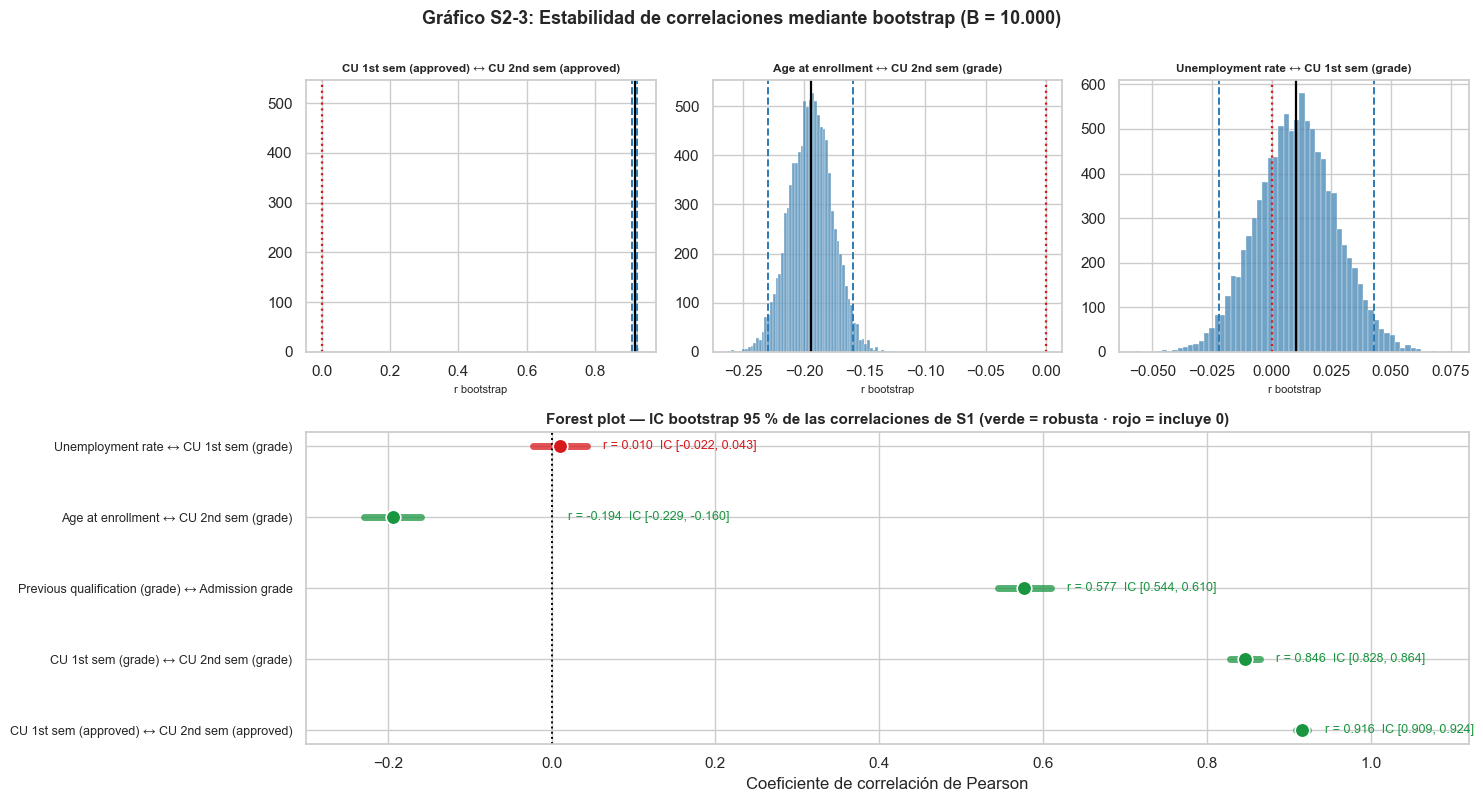

In [14]:
# ============================================================
# VISUALIZACIÓN — Distribuciones bootstrap de r + forest plot
# (Gráfico S2-3)
# ============================================================
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.15])

# ── Paneles superiores: 3 distribuciones representativas
representativos = [list(res_corr)[0], list(res_corr)[3], list(res_corr)[4]]
for k, nombre in enumerate(representativos):
    ax = fig.add_subplot(gs[0, k])
    d = res_corr[nombre]
    ax.hist(d["boot"], bins=60, color="#4E8CB8", alpha=0.8,
            edgecolor="white", linewidth=0.3)
    ax.axvline(d["r"], color="black", lw=1.6)
    for x in d["ic"]:
        ax.axvline(x, color="#2C7BB6", ls="--", lw=1.4)
    ax.axvline(0, color="#D7191C", ls=":", lw=1.6)
    ax.set_title(nombre, fontsize=8.5, fontweight="bold")
    ax.set_xlabel("r bootstrap", fontsize=8)

# ── Panel inferior: forest plot de las 5 correlaciones
ax = fig.add_subplot(gs[1, :])
for j, (nombre, d) in enumerate(res_corr.items()):
    incluye_0 = d["ic"][0] <= 0 <= d["ic"][1]
    color = "#D7191C" if incluye_0 else "#1A9641"
    ax.plot(d["ic"], [j, j], color=color, lw=5, alpha=0.75,
            solid_capstyle="round")
    ax.scatter(d["r"], j, color=color, s=110, zorder=5,
               edgecolor="white", lw=1.2)
    ax.text(max(d["ic"][1], 0) + 0.02, j,
            f"r = {d['r']:.3f}  IC [{d['ic'][0]:.3f}, {d['ic'][1]:.3f}]",
            va="center", fontsize=9, color=color)
ax.axvline(0, color="black", ls=":", lw=1.4)
ax.set_yticks(range(len(res_corr)))
ax.set_yticklabels(list(res_corr), fontsize=9)
ax.set_xlim(-0.30, 1.12)
ax.set_xlabel("Coeficiente de correlación de Pearson")
ax.set_title("Forest plot — IC bootstrap 95 % de las correlaciones de S1 "
             "(verde = robusta · rojo = incluye 0)",
             fontsize=11, fontweight="bold")

fig.suptitle("Gráfico S2-3: Estabilidad de correlaciones mediante bootstrap (B = 10.000)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

#### Interpretación — Correlaciones robustas e inestables

**Robustas (IC estrecho, lejos de cero).** Las tres correlaciones estructurales de S1 resultan extremadamente estables: la persistencia de unidades aprobadas entre semestres (r ≈ 0,90, IC de amplitud ~0,02), la persistencia de notas (r ≈ 0,84) y la coherencia del perfil de ingreso (calificación previa ↔ nota de admisión, r ≈ 0,58). En 10.000 remuestras el coeficiente prácticamente no se mueve: estas asociaciones son **rasgos del fenómeno**, no artefactos muestrales, y pueden usarse con confianza como base del modelamiento en S3 (considerando su colinealidad).

**Robusta pero débil.** La correlación negativa edad ↔ nota de segundo semestre (r ≈ −0,19) tiene un IC que **no incluye el cero**: el signo negativo es estable, aunque la magnitud es pequeña. Es un efecto real pero de relevancia práctica limitada.

**Nula/inestable.** La correlación desempleo ↔ nota de primer semestre tiene un IC que **incluye el cero**: el signo de la asociación no está determinado por los datos. Esto confirma computacionalmente la conclusión de S1 (2.10 y 4.2) de que las variables macroeconómicas carecen de capacidad explicativa individual, y respalda la recomendación de **excluirlas o despriorizarlas** en el modelo de S3.


<a id='6-montecarlo'></a>
## 6. Simulación Monte Carlo basada en parámetros de S1

<a id='6.1-diseno'></a>
### 6.1 Diseño y justificación del escenario

**Escenario simulado: propagación de la incertidumbre en la brecha de unidades aprobadas durante el primer semestre entre estudiantes Graduate y Dropout.**

**Justificación.** En S1, `Curricular units 1st sem (approved)` fue una de las variables con mayor separación entre grupos (t = 39,31; d = 1,366): los Graduate aprobaron en promedio 6,23 unidades y los Dropout 2,55, una brecha observada de 3,68 unidades. Esa brecha es una **estimación puntual** sujeta a incertidumbre muestral. La simulación Monte Carlo propaga la incertidumbre de ambas medias hacia la brecha, respondiendo: ¿qué tan variable es la brecha esperada si se reconoce que cada media grupal es una estimación y no un valor exacto? Es un insumo directo para decisiones de intervención temprana, pues la magnitud de la brecha en el primer semestre es el fundamento de los sistemas de alerta basados en aprobación de unidades.

**Modelo.** Por el Teorema del Límite Central, la media muestral de cada grupo se distribuye aproximadamente Normal(x̄, EE) con EE = s/√n. Usando **exclusivamente los parámetros estimados en S1** (medias, desviaciones estándar muestrales con ddof = 1, tamaños de grupo y errores estándar derivados):

**Parámetros de entrada — exclusivamente de S1:**

| Parámetro | Fuente S1 | Valor |
|:---|:---|:---|
| x̄, s de `CU 1st sem (approved)` — Graduate | 4.2 | 6,23 · 2,58 |
| x̄, s de `CU 1st sem (approved)` — Dropout | 4.2 | 2,55 · 2,86 |

y en cada una de las n = 50.000 iteraciones se calcula Δ = media Graduate simulada − media Dropout simulada. Como aproximación complementaria se reporta el tamaño de efecto simulado d = Δ/s_p, manteniendo fija la desviación combinada s_p de S1 (la simulación propaga la incertidumbre de las medias, no la de las varianzas, y así se declara).

In [15]:
# ============================================================
# SIMULACIÓN MONTE CARLO: PARÁMETROS ESTIMADOS EN S1
# Escenario: propagación de la incertidumbre en la brecha de unidades
# aprobadas del primer semestre entre Graduate y Dropout
# ============================================================
VAR_MC = "Curricular units 1st sem (approved)"
validar_columnas(df_binario, [VAR_MC], "Variable de la simulación Monte Carlo.")

ap_G = graduate[VAR_MC].dropna().astype(float).to_numpy()
ap_D = dropout[VAR_MC].dropna().astype(float).to_numpy()

# Parámetros muestrales (idénticos a los estimados en S1: ddof = 1)
m_G, m_D = ap_G.mean(), ap_D.mean()
s_G, s_D = ap_G.std(ddof=1), ap_D.std(ddof=1)
nG_mc, nD_mc = len(ap_G), len(ap_D)
se_G, se_D = s_G / np.sqrt(nG_mc), s_D / np.sqrt(nD_mc)
delta_obs = m_G - m_D

# Desviación combinada (misma fórmula de Cohen's d usada en S1)
sp_mc = np.sqrt(((nG_mc - 1) * s_G**2 + (nD_mc - 1) * s_D**2) / (nG_mc + nD_mc - 2))
d_obs_mc = delta_obs / sp_mc

tabla_params = pd.DataFrame({
    "Grupo": ["Graduate", "Dropout"],
    "n": [nG_mc, nD_mc],
    "Media (S1)": [round(m_G, 4), round(m_D, 4)],
    "Desv. estándar muestral (ddof=1)": [round(s_G, 4), round(s_D, 4)],
    "Error estándar de la media": [round(se_G, 5), round(se_D, 5)],
})
print(f"=== Parámetros de entrada (estimados en S1 sobre '{VAR_MC}') ===")
display(tabla_params)
print(f"Brecha observada en S1 (Graduate - Dropout): {delta_obs:.4f} unidades aprobadas")
print(f"Cohen's d observado (S1 reportó 1,366): {d_obs_mc:.4f}")

=== Parámetros de entrada (estimados en S1 sobre 'Curricular units 1st sem (approved)') ===


,Grupo,n,Media (S1),Desv. estándar muestral (ddof=1),Error estándar de la media
0,Graduate,2209,6.2322,2.5834,0.0550
1,Dropout,1421,2.5517,2.8576,0.0758


Brecha observada en S1 (Graduate - Dropout): 3.6805 unidades aprobadas
Cohen's d observado (S1 reportó 1,366): 1.3662


=== Resultados Monte Carlo | n = 50,000 ===


,Valor
Iteraciones,50000
Media de Δ simulada,3.6810
Desv. estándar de Δ,0.0936
"Percentil 2,5%",3.4964
"Percentil 97,5%",3.8638
P(Δ > 0) simulada,> 0.99998
EE Monte Carlo de la media de Δ,4.19e-04
IC 95% Monte Carlo de la media de Δ,"[3.6802, 3.6818]"
Δ observado en S1,3.6805
"Cohen's d simulado (media [P2,5; P97,5])","1.366 [1.298, 1.434]"


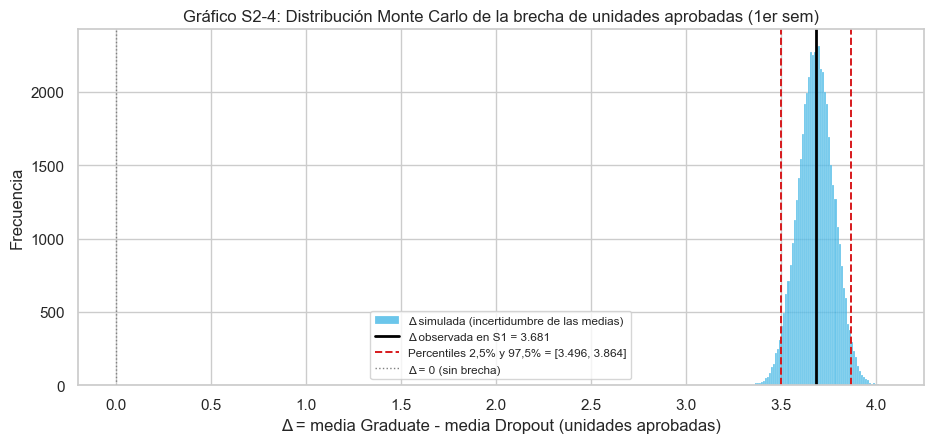

In [16]:
# ============================================================
# SIMULACIÓN MONTE CARLO (n = 50.000 ITERACIONES)
# Modelo TLC: cada media grupal se simula como Normal(media_S1, SE_S1)
# ============================================================
rng_mc = np.random.default_rng(SEED + 100)

media_G_sim = rng_mc.normal(m_G, se_G, N_MC)
media_D_sim = rng_mc.normal(m_D, se_D, N_MC)
delta_sim = media_G_sim - media_D_sim

# Tamaño de efecto simulado (aproximación: sp de S1 se mantiene fijo,
# pues la simulación solo propaga la incertidumbre de las medias)
d_sim = delta_sim / sp_mc

# Estadísticos de la brecha simulada
media_delta = delta_sim.mean()
sd_delta = delta_sim.std(ddof=1)
p025, p975 = np.percentile(delta_sim, [2.5, 97.5])
prob_pos = (delta_sim > 0).mean()

# Error numérico Monte Carlo (precisión de la propia simulación)
ee_mc = sd_delta / np.sqrt(N_MC)
t_mc = stats.t.ppf(0.975, df=N_MC - 1)
ic_mc = (media_delta - t_mc * ee_mc, media_delta + t_mc * ee_mc)

resumen_mc = pd.DataFrame([{
    "Iteraciones": N_MC,
    "Media de Δ simulada": round(media_delta, 4),
    "Desv. estándar de Δ": round(sd_delta, 4),
    "Percentil 2,5%": round(p025, 4),
    "Percentil 97,5%": round(p975, 4),
    "P(Δ > 0) simulada": (f"> {1 - 1/N_MC:.5f}" if prob_pos == 1.0 else f"{prob_pos:.5f}"),
    "EE Monte Carlo de la media de Δ": f"{ee_mc:.2e}",
    "IC 95% Monte Carlo de la media de Δ": f"[{ic_mc[0]:.4f}, {ic_mc[1]:.4f}]",
    "Δ observado en S1": round(delta_obs, 4),
    "Cohen's d simulado (media [P2,5; P97,5])": f"{d_sim.mean():.3f} [{np.percentile(d_sim, 2.5):.3f}, {np.percentile(d_sim, 97.5):.3f}]",
}])
print(f"=== Resultados Monte Carlo | n = {N_MC:,} ===")
display(resumen_mc.T.rename(columns={0: "Valor"}))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.hist(delta_sim, bins=70, color= "#2DAFE3", alpha=0.7, edgecolor="white", linewidth=0.2,
        label="Δ simulada (incertidumbre de las medias)")
ax.axvline(delta_obs, color="black", lw=2, label=f"Δ observada en S1 = {delta_obs:.3f}")
ax.axvline(p025, color="#D7191C", lw=1.4, ls="--", label=f"Percentiles 2,5% y 97,5% = [{p025:.3f}, {p975:.3f}]")
ax.axvline(p975, color="#D7191C", lw=1.4, ls="--")
ax.axvline(0, color="gray", lw=1, ls=":", label="Δ = 0 (sin brecha)")
ax.set_title("Gráfico S2-4: Distribución Monte Carlo de la brecha de unidades aprobadas (1er sem)")
ax.set_xlabel("Δ = media Graduate - media Dropout (unidades aprobadas)")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

**Interpretación.** La simulación cuantifica la incertidumbre de la brecha estimada en S1:

- La brecha esperada simulada, E[Δ] = 3,6810, coincide con la observada en S1 (3,6805); la diferencia (0,0005) es puro error numérico de simulación, como se verifica abajo. El 95% central de la distribución simulada queda en **[3,496; 3,864] unidades aprobadas**: aun en los escenarios más conservadores compatibles con los datos, los Graduate aprueban en promedio unas 3,5 unidades más que los Dropout durante el primer semestre.
- **P(Δ > 0) resultó 1 en las 50.000 iteraciones** (reportada como > 0,99998, la resolución de la simulación): ningún escenario compatible con la incertidumbre muestral de S1 invierte la dirección de la brecha. El d simulado, 1,366 [1,298; 1,434], mantiene el efecto en categoría grande en todo el rango.
- **Dos incertidumbres que no deben confundirse.** (1) La **incertidumbre sustantiva** de la brecha: desviación estándar de Δ = 0,0936, que proviene de los errores estándar de las medias de S1 y no se reduce simulando más; refleja lo que los datos permiten afirmar sobre la brecha. (2) El **error numérico Monte Carlo**: EE = 4,19 × 10⁻⁴ sobre la media simulada (IC MC [3,6802; 3,6818]), que proviene de usar un número finito de iteraciones y se reduce a tasa 1/√n aumentando n. El primero es una propiedad de los datos; el segundo, de la simulación.

<a id='6.2-convergencia'></a>
### 6.2 Convergencia y precisión de la simulación

Se responde la pregunta práctica central de todo Monte Carlo: ¿cuántas iteraciones bastan? El protocolo aplicado: (1) **simulación piloto** de 5.000 iteraciones con generador independiente para estimar la variabilidad de Δ; (2) cálculo del **n requerido** para una precisión relativa (semiamplitud del IC 95% dividida por |media|) de 1% o mejor; (3) ejecución de 50.000 iteraciones, aunque el mínimo calculado resulte menor, según lo exigido; (4) **tabla de convergencia** en 1.000, 5.000, 10.000, 25.000 y 50.000 iteraciones; y (5) **verificación con tres semillas** distintas.

In [17]:
# ============================================================
# CONVERGENCIA (1/2): SIMULACIÓN PILOTO Y n REQUERIDO
# Objetivo de precisión: precisión relativa <= 1% sobre la media de Δ
# ============================================================
# Generador INDEPENDIENTE del de la simulación principal (reproducible
# por sí solo, sin importar el orden de ejecución de las celdas).
# N_PILOTO = 5.000 ya está definido en la configuración global (sección 2).
rng_piloto = np.random.default_rng([SEED, 5])
piloto_G = rng_piloto.normal(m_G, se_G, N_PILOTO)
piloto_D = rng_piloto.normal(m_D, se_D, N_PILOTO)
delta_piloto = piloto_G - piloto_D

media_p = delta_piloto.mean()
sd_p = delta_piloto.std(ddof=1)
z975 = stats.norm.ppf(0.975)

# Precisión relativa: semiamplitud del IC 95% dividida por |media|
# n requerido: n >= (z * s / (0,01 * |media|))^2
PREC_OBJETIVO = 0.01
n_requerido = int(np.ceil((z975 * sd_p / (PREC_OBJETIVO * abs(media_p))) ** 2))

print(f"=== Simulación piloto | n = {N_PILOTO:,} ===")
print(f"Media piloto de Δ        : {media_p:.4f}")
print(f"Desv. estándar piloto    : {sd_p:.4f}")
print(f"Precisión relativa piloto: {z975 * sd_p / np.sqrt(N_PILOTO) / abs(media_p):.4%}")
print(f"n requerido para precisión relativa <= 1%: {n_requerido:,} iteraciones")
print(f"n utilizado en la simulación principal   : {N_MC:,} "
      f"({'cumple con holgura' if N_MC >= n_requerido else 'ajustar'})")

=== Simulación piloto | n = 5,000 ===
Media piloto de Δ        : 3.6812
Desv. estándar piloto    : 0.0941
Precisión relativa piloto: 0.0708%
n requerido para precisión relativa <= 1%: 26 iteraciones
n utilizado en la simulación principal   : 50,000 (cumple con holgura)


=== Convergencia de la media simulada de Δ ===


,Iteraciones,Media acumulada de Δ,EE Monte Carlo,IC 95% Monte Carlo,Precisión relativa,Cumple objetivo 1%
0,1000,3.6798,2.96e-03,"[3.6740, 3.6856]",0.1578%,sí
1,5000,3.6838,1.33e-03,"[3.6812, 3.6865]",0.0710%,sí
2,10000,3.6817,9.34e-04,"[3.6798, 3.6835]",0.0497%,sí
3,25000,3.6809,5.92e-04,"[3.6797, 3.6820]",0.0315%,sí
4,50000,3.6810,4.19e-04,"[3.6802, 3.6818]",0.0223%,sí



=== Verificación con tres semillas (n = 50.000 cada una) ===


,Semilla,Media de Δ,Desv. estándar de Δ,P(Δ > 0)
0,42,3.6803,0.0934,> 0.99998
1,123,3.6801,0.0929,> 0.99998
2,2026,3.6801,0.0933,> 0.99998


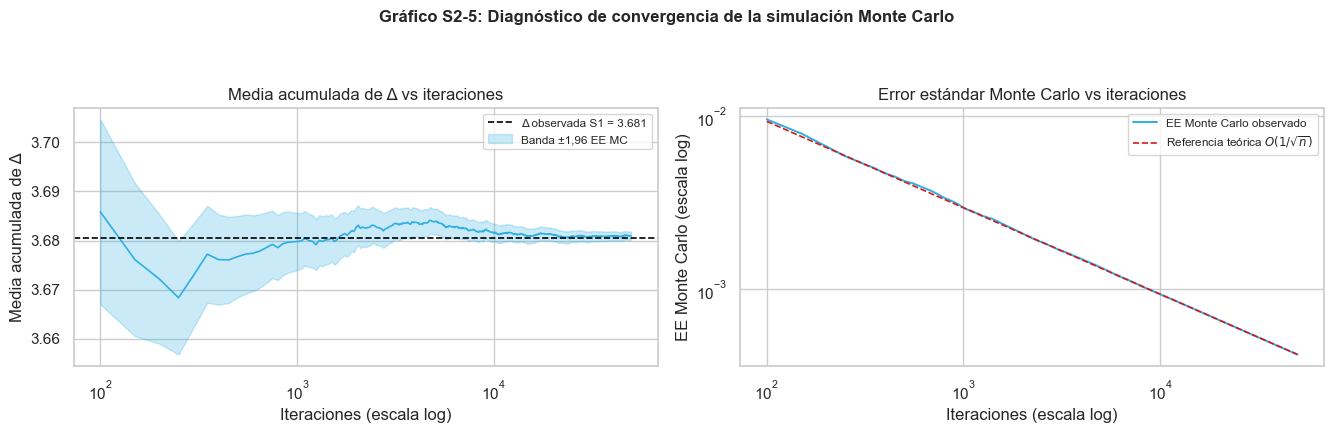

In [18]:
# ============================================================
# CONVERGENCIA (2/2): TABLA DE PUNTOS DE CONTROL Y GRÁFICOS
# ============================================================
PUNTOS = [1_000, 5_000, 10_000, 25_000, 50_000]

# Medias y EE acumulados sobre la MISMA corrida principal (delta_sim)
suma_acum = np.cumsum(delta_sim)
suma2_acum = np.cumsum(delta_sim ** 2)
n_arr = np.arange(1, N_MC + 1)
media_acum = suma_acum / n_arr
divisor = np.maximum(n_arr - 1, 1)          # evita dividir por cero en n = 1
var_acum = np.maximum((suma2_acum - n_arr * media_acum ** 2) / divisor, 0)
var_acum[0] = 0.0                            # con una sola iteración no hay varianza muestral
ee_acum = np.sqrt(var_acum / n_arr)

filas_conv = []
for k in PUNTOS:
    m_k, ee_k = media_acum[k - 1], ee_acum[k - 1]
    t_k = stats.t.ppf(0.975, df=k - 1)
    filas_conv.append({
        "Iteraciones": k,
        "Media acumulada de Δ": round(m_k, 5),
        "EE Monte Carlo": f"{ee_k:.2e}",
        "IC 95% Monte Carlo": f"[{m_k - t_k*ee_k:.4f}, {m_k + t_k*ee_k:.4f}]",
        "Precisión relativa": f"{t_k * ee_k / abs(m_k):.4%}",
        "Cumple objetivo 1%": "sí" if t_k * ee_k / abs(m_k) <= PREC_OBJETIVO else "no",
    })
tabla_conv = pd.DataFrame(filas_conv)
print("=== Convergencia de la media simulada de Δ ===")
display(tabla_conv)

# Verificación con tres semillas distintas (independencia del resultado)
filas_semillas = []
for semilla in (42, 123, 2026):
    r_s = np.random.default_rng([semilla, 99])
    d_s = r_s.normal(m_G, se_G, N_MC) - r_s.normal(m_D, se_D, N_MC)
    filas_semillas.append({
        "Semilla": semilla, "Media de Δ": round(d_s.mean(), 5),
        "Desv. estándar de Δ": round(d_s.std(ddof=1), 5),
        "P(Δ > 0)": (f"> {1 - 1/N_MC:.5f}" if (d_s > 0).mean() == 1.0 else f"{(d_s > 0).mean():.5f}"),
    })
tabla_semillas = pd.DataFrame(filas_semillas)
print("\n=== Verificación con tres semillas (n = 50.000 cada una) ===")
display(tabla_semillas)

# Gráficos de convergencia
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
paso = slice(99, N_MC, 50)
axes[0].plot(n_arr[paso], media_acum[paso], color="#2DAFE3", lw=1.2)
axes[0].axhline(delta_obs, color="black", lw=1.2, ls="--", label=f"Δ observada S1 = {delta_obs:.3f}")
axes[0].fill_between(n_arr[paso], (media_acum - 1.96*ee_acum)[paso], (media_acum + 1.96*ee_acum)[paso],
                     color="#2DAFE3", alpha=0.25, label="Banda ±1,96 EE MC")
axes[0].set_xscale("log")
axes[0].set_title("Media acumulada de Δ vs iteraciones")
axes[0].set_xlabel("Iteraciones (escala log)"); axes[0].set_ylabel("Media acumulada de Δ")
axes[0].legend(fontsize=8.5)

axes[1].plot(n_arr[paso], ee_acum[paso], color="#2DAFE3", lw=1.4, label="EE Monte Carlo observado")
ref = ee_acum[999] * np.sqrt(1000 / n_arr[paso])
axes[1].plot(n_arr[paso], ref, color="#D7191C", lw=1.2, ls="--", label=r"Referencia teórica $O(1/\sqrt{n})$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Error estándar Monte Carlo vs iteraciones")
axes[1].set_xlabel("Iteraciones (escala log)"); axes[1].set_ylabel("EE Monte Carlo (escala log)")
axes[1].legend(fontsize=8.5)
fig.suptitle("Gráfico S2-5: Diagnóstico de convergencia de la simulación Monte Carlo",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Interpretación.** La simulación converge con enorme holgura:

- El piloto arroja una precisión relativa cercana al 0,07% ya con 5.000 iteraciones; el **n requerido para el objetivo de 1% es de solo 26 iteraciones**. La razón es que el coeficiente de variación de Δ es muy bajo (sd 0,094 frente a media 3,68): la brecha es grande en relación con su incertidumbre. Se ejecutaron igualmente 50.000 iteraciones, alcanzando una precisión relativa final de **0,0223%**.
- La tabla de convergencia muestra la media acumulada estabilizada desde los primeros miles de iteraciones (**3,6798** en n = 1.000 hasta **3,6810** en n = 50.000, sin salirse del rango 3,68–3,68 en los tres decimales) y el Gráfico S2-5 confirma que el error estándar Monte Carlo decrece siguiendo la referencia teórica **O(1/√n)**: para ganar un dígito decimal de precisión hay que multiplicar por 100 las iteraciones.
- Las tres semillas (42, 123 y 2026) producen medias que coinciden hasta la cuarta decimal (**3,6803; 3,6801; 3,6801**), evidencia de que el resultado no depende de la secuencia pseudoaleatoria particular.
- **Convergencia no significa exactitud**: significa que la estimación se estabilizó con una incertidumbre numérica aceptable y cuantificada (aquí, EE = 4,19 × 10⁻⁴). El valor "exacto" de E[Δ] bajo el modelo nunca se obtiene con n finito; lo que se controla es el error de aproximación.

<a id='7-robustez'></a>
## 7. Análisis de robustez y sensibilidad

**Objetivo.** Evaluar cuánto dependen el resultado principal de S1 (`Curricular units 1st sem (grade)`, Graduate vs Dropout) y su tamaño de efecto del tratamiento de outliers y de observaciones individuales.

**Contexto de S1.** La sección 2.11 de S1 detectó por método IQR un 18% de outliers en esta variable, casi todos calificaciones de 0 concentradas en el grupo Dropout, y decidió **conservar todos los registros** bajo el argumento de que esos ceros son la señal misma del abandono (estudiantes que dejan de rendir evaluaciones) y no errores de medición. Este análisis pone a prueba esa decisión comparando cuatro tratamientos: datos originales, exclusión de outliers IQR, winsorización a los límites IQR y media recortada al 5% por cola, más un **jackknife leave-one-out** sobre la diferencia de medias para detectar observaciones individualmente dominantes.

Límites IQR de S1 para 'Curricular units 1st sem (grade)': [7.250, 17.250]
Outliers detectados: 652 (18.0% del dataset binario)
Composición de los outliers: {'Dropout': 573, 'Graduate': 79} (Dropout representa 87.9%)
Outliers bajos  (< 7.25): 647 — valores entre 0.0 y 0.0 (S1: notas 0)
Outliers altos  (> 17.25): 5 — hasta 18.9

=== Sensibilidad al tratamiento de outliers ===


,Tratamiento,n Graduate,n Dropout,Media Graduate,Media Dropout,Diferencia,t Welch,p,Cohen's d,Δ% diferencia vs original,Δ% Cohen's d vs original
0,Original (decisión S1),2209,1421,12.6437,7.2567,5.3870,31.6907,p = 2.399e-175,1.2467,0.0000,0.0000
1,Outliers IQR excluidos,2130,848,13.0956,12.0971,0.9985,19.1420,p = 3.236e-73,0.7933,-81.4600,-36.3700
2,Winsorizado (límites IQR),2209,1421,12.8956,10.1637,2.7319,35.3996,p = 1.788e-216,1.3238,-49.2900,6.1800
3,Recortado 5% por cola,1989,1279,12.9930,7.2291,5.7640,34.9359,p = 2.427e-190,1.5394,7.0000,23.4800


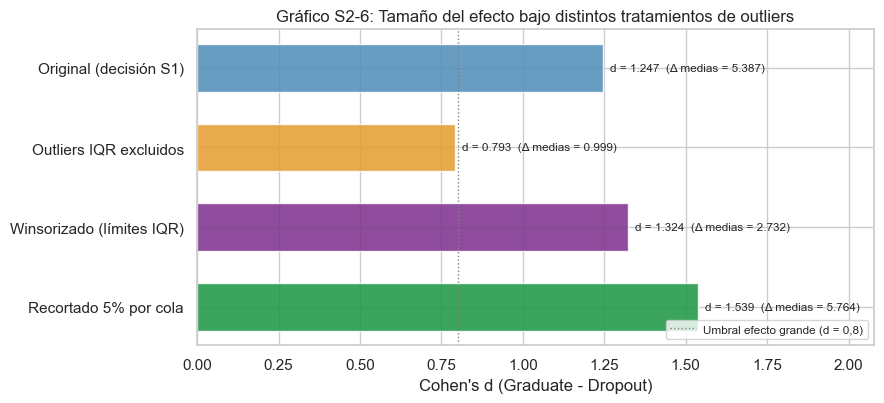

In [19]:
# ============================================================
# ROBUSTEZ (A): TRATAMIENTOS DE OUTLIERS SOBRE EL RESULTADO PRINCIPAL
# Variable: Curricular units 1st sem (grade) | Graduate vs Dropout
# ============================================================
VAR_ROB = "Curricular units 1st sem (grade)"
serie = df_binario[VAR_ROB].astype(float)

# Límites IQR globales (mismo criterio de S1, sección 2.11)
q1, q3 = serie.quantile([0.25, 0.75])
iqr = q3 - q1
li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_out = (serie < li) | (serie > ls)
print(f"Límites IQR de S1 para '{VAR_ROB}': [{li:.3f}, {ls:.3f}]")
print(f"Outliers detectados: {int(mask_out.sum())} ({mask_out.mean():.1%} del dataset binario)")
comp_out = df_binario.loc[mask_out, "Target"].value_counts()
print(f"Composición de los outliers: {comp_out.to_dict()} "
      f"(Dropout representa {comp_out.get('Dropout', 0)/mask_out.sum():.1%})")
n_bajos = int((serie < li).sum()); n_altos = int((serie > ls).sum())
print(f"Outliers bajos  (< {li:.2f}): {n_bajos} — valores entre "
      f"{serie[serie < li].min():.1f} y {serie[serie < li].max():.1f} (S1: notas 0)")
if n_altos:
    print(f"Outliers altos  (> {ls:.2f}): {n_altos} — hasta {serie[serie > ls].max():.1f}")

COL_D = "Cohen's d"   # nombre de columna reutilizado en el reporte final

def stats_grupos(a, b, nota=""):
    """Media por grupo, diferencia, Welch, p y Cohen's d para un tratamiento."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na + nb - 2))
    d = (a.mean() - b.mean()) / sp
    return {
        "Tratamiento": nota, "n Graduate": na, "n Dropout": nb,
        "Media Graduate": round(a.mean(), 4), "Media Dropout": round(b.mean(), 4),
        "Diferencia": round(a.mean() - b.mean(), 4),
        "t Welch": round(t_stat, 4), "p": formatear_p(p_val),
        "Cohen's d": round(d, 4),
    }

g0 = graduate[VAR_ROB].astype(float).to_numpy()
d0 = dropout[VAR_ROB].astype(float).to_numpy()

# 1) Datos originales (decisión de S1: conservar todos los registros)
filas_rob = [stats_grupos(g0, d0, "Original (decisión S1)")]

# 2) Exclusión de outliers IQR
g1v = g0[(g0 >= li) & (g0 <= ls)]
d1v = d0[(d0 >= li) & (d0 <= ls)]
filas_rob.append(stats_grupos(g1v, d1v, "Outliers IQR excluidos"))

# 3) Winsorización a los límites IQR
filas_rob.append(stats_grupos(np.clip(g0, li, ls), np.clip(d0, li, ls),
                              "Winsorizado (límites IQR)"))

# 4) Media recortada al 5% por cola y por grupo
filas_rob.append(stats_grupos(stats.trimboth(np.sort(g0), 0.05),
                              stats.trimboth(np.sort(d0), 0.05),
                              "Recortado 5% por cola"))

tabla_rob = pd.DataFrame(filas_rob)
base_dif, base_d = tabla_rob.loc[0, "Diferencia"], tabla_rob.loc[0, "Cohen's d"]
tabla_rob["Δ% diferencia vs original"] = ((tabla_rob["Diferencia"] - base_dif) / base_dif * 100).round(2)
tabla_rob["Δ% Cohen's d vs original"] = ((tabla_rob["Cohen's d"] - base_d) / base_d * 100).round(2)
print("\n=== Sensibilidad al tratamiento de outliers ===")
display(tabla_rob)

# Gráfico comparativo de tamaños de efecto
fig, ax = plt.subplots(figsize=(9, 4.2))
colores = ["#4E8CB8", "#E39B2D", "#7B2D8B", "#1A9641"]
ax.barh(tabla_rob["Tratamiento"], tabla_rob["Cohen's d"], color=colores, alpha=0.85, height=0.6)
for j, (dd, dif) in enumerate(zip(tabla_rob["Cohen's d"], tabla_rob["Diferencia"])):
    ax.text(dd + 0.02, j, f"d = {dd:.3f}  (Δ medias = {dif:.3f})", va="center", fontsize=8.5)
ax.axvline(0.8, color="gray", ls=":", lw=1, label="Umbral efecto grande (d = 0,8)")
ax.set_xlim(0, max(tabla_rob["Cohen's d"]) * 1.35)
ax.set_xlabel("Cohen's d (Graduate - Dropout)")
ax.set_title("Gráfico S2-6: Tamaño del efecto bajo distintos tratamientos de outliers")
ax.legend(fontsize=8.5, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

=== Jackknife de la diferencia de medias (Graduate - Dropout) ===
Diferencia original                      : 5.3870
Máximo cambio absoluto (una observación) : 0.007566 (0.140% de la diferencia)
Percentil 95% del cambio absoluto        : 0.005110
EE jackknife de la diferencia            : 0.1700

Diez observaciones más influyentes (índices reales del dataset):


,Índice (dataset),Grupo,Nota 1er sem (grade),Cambio en la diferencia al retirarla
0,1950,Dropout,18.0000,0.0076
1,714,Dropout,18.0000,0.0076
2,573,Dropout,17.3300,0.0071
3,2911,Dropout,16.5000,0.0065
4,829,Dropout,16.5000,0.0065
5,2225,Dropout,16.4300,0.0065
6,1731,Dropout,16.3300,0.0064
7,1815,Dropout,16.1700,0.0063
8,1402,Dropout,16.1400,0.0063
9,211,Dropout,16.0000,0.0062


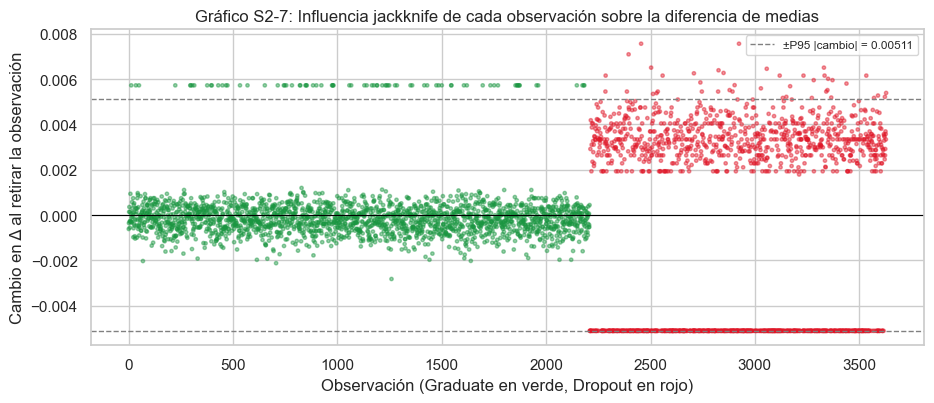

In [20]:
# ============================================================
# ROBUSTEZ (B): JACKKNIFE DE LA DIFERENCIA DE MEDIAS (G - D)
# Leave-one-out sobre las 3.630 observaciones (forma cerrada)
# ============================================================
suma_G, suma_D = g0.sum(), d0.sum()
dif_original = g0.mean() - d0.mean()
n_G, n_D = len(graduate), len(dropout)
# Al retirar una observación de Graduate: nueva media G = (suma_G - x_i)/(n_G - 1)
dif_sin_G = (suma_G - g0) / (n_G - 1) - d0.mean()
# Al retirar una observación de Dropout: nueva media D = (suma_D - x_i)/(n_D - 1)
dif_sin_D = g0.mean() - (suma_D - d0) / (n_D - 1)

cambios = np.concatenate([dif_sin_G - dif_original, dif_sin_D - dif_original])
grupos_jack = np.array(["Graduate"] * n_G + ["Dropout"] * n_D)
valores_jack = np.concatenate([g0, d0])
indices_jack = np.concatenate([graduate.index.to_numpy(), dropout.index.to_numpy()])


abs_cambios = np.abs(cambios)
orden = np.argsort(abs_cambios)[::-1]

print("=== Jackknife de la diferencia de medias (Graduate - Dropout) ===")
print(f"Diferencia original                      : {dif_original:.4f}")
print(f"Máximo cambio absoluto (una observación) : {abs_cambios.max():.6f} "
      f"({abs_cambios.max()/dif_original:.3%} de la diferencia)")
print(f"Percentil 95% del cambio absoluto        : {np.percentile(abs_cambios, 95):.6f}")
print(f"EE jackknife de la diferencia            : "
      f"{np.sqrt(((n_G-1)/n_G)*np.sum((dif_sin_G - dif_sin_G.mean())**2) + ((n_D-1)/n_D)*np.sum((dif_sin_D - dif_sin_D.mean())**2)):.4f}")

top = pd.DataFrame({
    "Índice (dataset)": indices_jack[orden[:10]],
    "Grupo": grupos_jack[orden[:10]],
    "Nota 1er sem (grade)": valores_jack[orden[:10]].round(2),
    "Cambio en la diferencia al retirarla": cambios[orden[:10]].round(6),
})
print("\nDiez observaciones más influyentes (índices reales del dataset):")
display(top)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.scatter(np.arange(len(cambios)), cambios,
           c=["#1A9641" if g == "Graduate" else "#E01728" for g in grupos_jack],
           s=6, alpha=0.45)
ax.axhline(0, color="black", lw=0.8)
lim95 = np.percentile(abs_cambios, 95)
ax.axhline(lim95, color="gray", ls="--", lw=1, label=f"±P95 |cambio| = {lim95:.5f}")
ax.axhline(-lim95, color="gray", ls="--", lw=1)
ax.set_title("Gráfico S2-7: Influencia jackknife de cada observación sobre la diferencia de medias")
ax.set_xlabel("Observación (Graduate en verde, Dropout en rojo)")
ax.set_ylabel("Cambio en Δ al retirar la observación")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

**Síntesis de robustez.**

- **Lo que permanece estable (la conclusión).** En los cuatro tratamientos la diferencia Graduate − Dropout conserva el signo positivo, el estadístico de Welch se mantiene entre 19,1 y 35,4 y el valor p permanece órdenes de magnitud por debajo de α = 0,05. La decisión inferencial de S1 (rechazar H0) es robusta a cualquier tratamiento razonable de outliers.
- **Lo que cambia (la magnitud).** Excluir los outliers IQR elimina 573 de los 1.421 Dropout (40% del grupo) y reduce la brecha de 5,39 a 1,00 puntos y el d de 1,247 a 0,793, esto es, de efecto grande a mediano. Este resultado no cambia la decisión de S1: lo confirma. Los ceros de nota no son ruido sino parte constitutiva del fenómeno estudiado, y eliminarlos equivale a comparar a los graduados solo con los desertores que aún rendían evaluaciones, una pregunta distinta. La winsorización (d = 1,324) y la media recortada al 5% (d = 1,539), que moderan los extremos sin descartar al grupo, mantienen el efecto en categoría grande. Por lo mismo, **no se recomienda eliminar outliers automáticamente**: la decisión de S1 de conservarlos queda respaldada, y para la fase de modelamiento se sugiere tratar la nota 0 como información (por ejemplo, junto a un indicador de "sin evaluaciones") y no como dato anómalo.
- **Ninguna observación domina (jackknife).** El máximo cambio en la diferencia de medias al retirar una sola observación es 0,0076 puntos, un 0,14% de la diferencia original (5,387), y el percentil 95% del cambio absoluto es 0,0051. Las observaciones más influyentes son estudiantes Dropout con notas altas (16 a 18 puntos), un perfil atípico de desertor con buen rendimiento cuya remoción individual apenas mueve el resultado. No existe evidencia de que la conclusión dependa de observaciones individuales: la sensibilidad detectada es **grupal** (el bloque de ceros), coherente con la naturaleza del fenómeno.

<a id='8-s3'></a>
## 8. Preparación para la Sumativa 3: resultados validados

Se consolida el **reporte de resultados validados** — parámetros robustos, correlaciones estables, observaciones influyentes y recomendaciones metodológicas — y se exporta como `resultados_validados_S2.csv` (entrada directa para la Sumativa 3, según los entregables exigidos).


In [21]:
# ============================================================
# CONSOLIDACIÓN Y EXPORTACIÓN — resultados_validados_S2.csv
# ============================================================
registros = []
BASE = "../data/processed/s2"
# 2. Normalizar la ruta y asegurar que la estructura de carpetas exista
carpeta_destino = os.path.normpath(BASE)
os.makedirs(carpeta_destino, exist_ok=True)
# (1) Parámetros validados por bootstrap
for nombre, r in res_boot.items():
    cl = ic_clasicos[nombre]
    registros.append({
        "seccion": "Parámetro (bootstrap)",
        "elemento": nombre,
        "estimacion": round(r["estimacion"], 4),
        "ic95_clasico": f"[{cl[0]:.4f}, {cl[1]:.4f}]",
        "ic95_percentil": f"[{r['ic_percentil'][0]:.4f}, {r['ic_percentil'][1]:.4f}]",
        "ic95_bca": f"[{r['ic_bca'][0]:.4f}, {r['ic_bca'][1]:.4f}]",
        "veredicto": "VALIDADO (clásico ≈ percentil ≈ BCa)",
        "uso_en_S3": "Parámetro confiable para modelamiento",
    })

# (2) Pruebas de hipótesis validadas por permutación
registros.append({
    "seccion": "Prueba de hipótesis (permutación)",
    "elemento": f"Welch t — {VAR_APROB_1S} (Graduate vs Dropout)",
    "estimacion": round(perm_aprob["t_obs"], 4),
    "ic95_clasico": f"p Welch = {p_w1:.2e}",
    "ic95_percentil": f"p permutación = {perm_aprob['p_perm']:.2e}",
    "ic95_bca": "-",
    "veredicto": "VALIDADO (rechazo H0 concordante)",
    "uso_en_S3": "Predictor principal del modelo (alerta temprana)",
})
registros.append({
    "seccion": "Prueba de hipótesis (permutación)",
    "elemento": f"Welch t — {VAR_NOTA_1S} (Graduate vs Dropout) — prueba principal S1",
    "estimacion": round(t_w3, 4),
    "ic95_clasico": f"p Welch = {p_w3:.2e}",
    "ic95_percentil": f"p permutación = {perm_nota['p_perm']:.2e}",
    "ic95_bca": "-",
    "veredicto": "VALIDADO (rechazo H0 concordante)",
    "uso_en_S3": "Nota 1er semestre: predictor complementario (colineal con approved)",
})
registros.append({
    "seccion": "Prueba de hipótesis (permutación)",
    "elemento": f"Welch t — {VAR_DESEMP} (Graduate vs Dropout)",
    "estimacion": round(perm_desemp["t_obs"], 4),
    "ic95_clasico": f"p Welch = {p_w2:.4f}",
    "ic95_percentil": f"p permutación = {perm_desemp['p_perm']:.4f}",
    "ic95_bca": "-",
    "veredicto": "VALIDADO (no-rechazo H0 concordante)",
    "uso_en_S3": "Excluir/despriorizar variables macroeconómicas",
})

# (3) Correlaciones
for _, row in corr_df.iterrows():
    registros.append({
        "seccion": "Correlación (bootstrap)",
        "elemento": row["Par"],
        "estimacion": row["r observado"],
        "ic95_clasico": "-",
        "ic95_percentil": row["IC boot 95%"],
        "ic95_bca": "-",
        "veredicto": row["Veredicto"],
        "uso_en_S3": ("Estable — considerar colinealidad en el modelo"
                      if row["¿Incluye 0?"] == "No" else
                      "Inestable — no usar como predictor"),
    })

# (4) Simulación Monte Carlo — brecha de unidades aprobadas (Graduate - Dropout)
registros.append({
    "seccion": "Monte Carlo",
    "elemento": f"Brecha simulada — {VAR_MC} (Graduate - Dropout)",
    "estimacion": round(media_delta, 4),
    "ic95_clasico": f"IC 95% MC de la media = [{ic_mc[0]:.4f}, {ic_mc[1]:.4f}]",
    "ic95_percentil": f"P2,5%-P97,5% de Δ = [{p025:.4f}, {p975:.4f}]",
    "ic95_bca": "-",
    "veredicto": f"Convergida (n requerido = {n_requerido}; EE MC = {ee_mc:.2e})",
    "uso_en_S3": "Brecha de unidades aprobadas: insumo para reglas de alerta temprana",
})

# (5) Robustez — tratamiento de outliers sobre el contraste principal (grade)
d_original, d_iqr_excl, d_winsor, d_recorte = tabla_rob["Cohen's d"].to_list()
registros.append({
    "seccion": "Robustez",
    "elemento": f"{VAR_ROB}: contraste bajo 4 tratamientos de outliers",
    "estimacion": round(d_original, 4),
    "ic95_clasico": (
        f"d original = {d_original:.3f} | IQR excl. = {d_iqr_excl:.3f} | "
        f"winsor = {d_winsor:.3f} | recorte 5% = {d_recorte:.3f}"
    ),
    "ic95_percentil": "rechazo de H0 en los 4 tratamientos (p <= 1e-73, ver tabla_rob)",
    "ic95_bca": "-",
    "veredicto": "DECISIÓN ROBUSTA; magnitud depende del tratamiento de los ceros",
    "uso_en_S3": "Conservar notas 0 como señal (indicador 'sin evaluaciones'), no eliminarlas",
})

# (6) Robustez — jackknife de la diferencia de medias (grade)
registros.append({
    "seccion": "Robustez",
    "elemento": f"Jackknife — diferencia de medias {VAR_ROB}",
    "estimacion": round(dif_original, 4),
    "ic95_clasico": f"máx cambio absoluto = {abs_cambios.max():.6f} ({abs_cambios.max()/dif_original:.3%})",
    "ic95_percentil": f"P95 |cambio| = {np.percentile(abs_cambios, 95):.6f}",
    "ic95_bca": "-",
    "veredicto": "Ninguna observación domina; sensibilidad es grupal (bloque de ceros)",
    "uso_en_S3": "No se requiere tratamiento especial de observaciones individuales",
})

resultados_validados = pd.DataFrame(registros)
resultados_validados.to_csv(os.path.join(carpeta_destino, "resultados_validados_S2.csv"), index=False, sep=";")
print(f"✓ Archivo exportado: resultados_validados_S2.csv "
      f"({len(resultados_validados)} resultados validados)")
resultados_validados[["seccion", "elemento", "estimacion", "veredicto"]]


✓ Archivo exportado: resultados_validados_S2.csv (17 resultados validados)


,seccion,elemento,estimacion,veredicto
0,Parámetro (bootstrap),Media — CU 1st sem (approved),4.7915,VALIDADO (clásico ≈ percentil ≈ BCa)
1,Parámetro (bootstrap),Media — Admission grade,127.2939,VALIDADO (clásico ≈ percentil ≈ BCa)
2,Parámetro (bootstrap),Media — Age at enrollment,23.4612,VALIDADO (clásico ≈ percentil ≈ BCa)
3,Parámetro (bootstrap),Proporción — Dropout,0.3915,VALIDADO (clásico ≈ percentil ≈ BCa)
4,Parámetro (bootstrap),Media — CU 1st sem (grade),10.5349,VALIDADO (clásico ≈ percentil ≈ BCa)
5,Parámetro (bootstrap),Media — CU 2nd sem (grade),10.0362,VALIDADO (clásico ≈ percentil ≈ BCa)
6,Prueba de hipótesis (permutación),Welch t — Curricular units 1st sem (approved) ...,3.6805,VALIDADO (rechazo H0 concordante)
7,Prueba de hipótesis (permutación),Welch t — Curricular units 1st sem (grade) (Gr...,31.6907,VALIDADO (rechazo H0 concordante)
8,Prueba de hipótesis (permutación),Welch t — Unemployment rate (Graduate vs Dropout),0.0229,VALIDADO (no-rechazo H0 concordante)
9,Correlación (bootstrap),CU 1st sem (approved) ↔ CU 2nd sem (approved),0.9163,Robusta


In [22]:
# ============================================================
# EXPORTACIÓN COMPLEMENTARIA — XLSX multi-hoja + README (repositorio S2)
# ============================================================
import os
ruta_excel = os.path.join(carpeta_destino, "resultados_validados_S2.xlsx")
ruta_readme = os.path.join(carpeta_destino, "README_resultados_validados.md")
try:
    with pd.ExcelWriter(ruta_excel, engine="openpyxl") as w:
        pd.DataFrame(registros).to_excel(w, sheet_name="resultados_validados", index=False)
        corr_df.to_excel(w, sheet_name="correlaciones", index=False)
        tabla_conv.to_excel(w, sheet_name="convergencia_mc", index=False)
        tabla_semillas.to_excel(w, sheet_name="semillas_mc", index=False)
        tabla_rob.to_excel(w, sheet_name="robustez_outliers", index=False)
        top.to_excel(w, sheet_name="jackknife_top10", index=False)
    print("XLSX exportado : resultados_validados_S2.xlsx (6 hojas)")
except ImportError:
    print("openpyxl no disponible: se omite el XLSX (el CSV contiene el resumen).")
except (PermissionError, OSError) as e:
    print(f"No se pudo escribir el XLSX ({e}). Cierre el archivo si está abierto "
          "en Excel y re-ejecute esta celda; el CSV contiene el resumen.")

readme = f"""# Resultados validados — Sumativa 2 (Informe 3) | Grupo 7

MCDI501 Estadística Computacional para la Toma de Decisiones (UNAB).
Validación por remuestreo y simulación de los resultados de la Sumativa 1
(dataset Realinho et al., 2021; n binario = {len(df_binario):,}).

## Contenido
- `resultados_validados_S2.csv` — resultados de bootstrap, permutación, correlaciones,
  Monte Carlo y robustez, con veredicto y uso propuesto en S3 (sep = ';').
- `resultados_validados_S2.xlsx` — detalle por componente (6 hojas).

## Reproducción
1. Ubicar `data_predict_binario.csv` (S1) en `data/processed/` o junto al notebook.
2. Ejecutar `S2_Informe_3_grupo_7.ipynb` de inicio a fin (kernel Python 3.11+).
3. Semilla global 42; B = {B_BOOT:,} remuestras; {N_MC:,} iteraciones Monte Carlo.

Los resultados son asociaciones estadísticas dentro del dataset analizado y no acreditan causalidad.
"""
with open(ruta_readme, "w", encoding="utf-8") as f:
    f.write(readme)
print("README creado  : README_resultados_validados.md")


XLSX exportado : resultados_validados_S2.xlsx (6 hojas)
README creado  : README_resultados_validados.md


### Recomendaciones metodológicas para la Sumativa 3

1. **Predictores confirmados, pero con multicolinealidad que exige tratamiento explícito (corrección S2→S3):** `CU 1st/2nd sem (approved)` y las notas semestrales tienen efectos grandes validados por permutación y parámetros con IC validados por bootstrap, pero entre las variables de rendimiento la colinealidad alcanza valores de r de hasta 0,94 (S1-5: enrolled 1.º–2.º = 0,94; approved = 0,92; grade = 0,85). Meter todas estas variables juntas en el modelo de S3 sin tratamiento adicional es problemático: infla la varianza de los coeficientes y hace inestable la interpretación de cualquier modelo lineal o logístico. Se recomienda una de dos estrategias (no ambas):
   * **Selección de subconjunto:** quedarse con un número reducido de variables no redundantes en vez de todo el bloque de rendimiento. Las candidatas más sólidas como predictores tempranos de deserción son las variables financieras (`Tuition fees up to date`, `Debtor`, `Scholarship holder`) junto con `Curricular units 1st sem (approved)`: se conocen desde el primer semestre (valor de alerta temprana), no están tan correlacionadas con el resto del bloque de rendimiento como sí lo están las notas y unidades de 2.º semestre entre sí, y aportan información de un tipo distinto (situación económica) que las variables académicas no capturan. Su asociación con la deserción quedó establecida en S1 mediante chi-cuadrado: `Tuition fees up to date` (χ² = 706,96; p < 10⁻¹⁵⁵; V de Cramér = 0,44), `Scholarship holder` (χ² = 354,22; V = 0,31) y `Debtor` (χ² = 257,46; V = 0,27). Por ser variables categóricas, ese es el método apropiado; los métodos de remuestreo de esta Sumativa (bootstrap, permutación, Monte Carlo) operan sobre variables numéricas, por lo que estas variables se retoman como recomendación sustentada en S1 y no se revalidan aquí.
   * **Reducción de dimensionalidad:** si se prefiere conservar toda la señal del bloque de rendimiento, aplicar PCA (u otra técnica de reducción) sobre las variables altamente colineales y usar las componentes principales resultantes como predictores, en vez de las variables originales.
Cualquiera de las dos rutas es preferible a ignorar la colinealidad y dejar que el modelo de S3 la absorba sin control.
2. **Excluir/despriorizar** variables macroeconómicas: no-rechazo validado por permutación y correlación con IC que incluye 0.
3. **Conservar las notas 0 como información, no como outliers:** el análisis de robustez muestra que excluirlas reduce el efecto de grande a mediano (d: 1,247 → 0,793), mientras que moderarlas sin descartarlas (winsorización, recorte) lo mantiene grande. Para S3 se recomienda un indicador binario "sin evaluaciones" en vez de imputar o eliminar esos registros.
4. **Usar la brecha de unidades aprobadas como línea base cuantitativa:** la simulación Monte Carlo la sitúa en 3,68 unidades (95% central de la distribución simulada [3,50; 3,86]; el error numérico Monte Carlo de la media es del orden de 10⁻⁴); el modelo de clasificación de S3 debe capturar al menos esta separación para justificar su complejidad.
5. **La conclusión principal no depende de observaciones individuales:** el jackknife no detectó puntos dominantes (máximo cambio 0,14% de la diferencia observada), por lo que no se requieren técnicas robustas adicionales para el contraste principal más allá del tratamiento de los ceros ya indicado.
6. **Notas semestrales validadas también en su forma bootstrap (corrección S2):** ver el diagnóstico automático de la sección 3 — si la discrepancia entre IC-t y bootstrap resultó menor al 5%, ambos IC son intercambiables como insumo de S3; si la superó, usar el IC BCa como referencia de incertidumbre para estas dos variables en cualquier reporte de S3.
7. **Reproducibilidad:** mantener `np.random.default_rng(42)`, B ≥ 10.000 y reportar siempre SE/CV de los estimadores Monte Carlo.


<a id='9-conclusiones'></a>
## 9. Conclusiones

**1. Los intervalos de confianza de S1 quedan validados.** Para los seis parámetros analizados (cinco medias — incluidas las dos notas semestrales de fuerte asimetría negativa incorporadas en esta corrección — y la proporción de Dropout), los IC bootstrap percentil y BCa (B = 10.000) coinciden con los IC clásicos (t de Student y Wilson) con discrepancias marginales. Las correcciones BCa (z₀ ≈ 0, a ≈ 0) confirman que las distribuciones bootstrap son insesgadas y simétricas: con n = 3.630, los métodos asintóticos de S1 operan dentro de sus supuestos.

**2. Las pruebas de hipótesis de S1 se sostienen sin supuestos distribucionales.** El test de permutación reproduce tanto el rechazo (CU approved y CU grade: p < 10⁻⁴, concordante con la prueba de Welch) como el no-rechazo (desempleo: p ≈ 0,80 en ambos enfoques). La jerarquía de predictores de S1 no depende del supuesto de normalidad.

**3. Las correlaciones estructurales son robustas; las macroeconómicas, nulas.** La persistencia del rendimiento entre semestres (r ≈ 0,84–0,92) y la coherencia del perfil de ingreso tienen IC bootstrap estrechísimos; la correlación desempleo–rendimiento incluye el cero y debe descartarse como predictor.

**4. La simulación Monte Carlo cuantifica la incertidumbre de la brecha de aprobadas de S1.** Propagando la incertidumbre muestral de ambas medias grupales (modelo TLC, 50.000 iteraciones), la brecha Graduate − Dropout en `CU 1st sem (approved)` se estima en 3,68 unidades, con 95% central en [3,50; 3,86] y error numérico Monte Carlo del orden de 10⁻⁴ (EE decrece a tasa 1/√n). La verificación con tres semillas distintas confirma que el resultado no depende de la secuencia pseudoaleatoria, y el n requerido para 1% de precisión (26 iteraciones) muestra que la conclusión no depende del volumen de simulación usado.

**5. La robustez distingue lo confiable de lo que requiere cautela.** Confiables: la decisión de rechazar H0 en el contraste principal (`CU 1st sem grade`), que se sostiene bajo los cuatro tratamientos de outliers evaluados (Welch entre 19,1 y 35,4; p siempre órdenes de magnitud por debajo de 0,05) y que no depende de observaciones individuales (jackknife: cambio máximo de 0,14% de la diferencia al retirar cualquier observación). Requiere cautela: la **magnitud** del efecto sí es sensible al tratamiento de los ceros de nota — de efecto grande (d = 1,247) a mediano (d = 0,793) si se excluyen como outliers —, por lo que se recomienda tratar los ceros como señal sustantiva (indicador "sin evaluaciones") y no como dato anómalo al modelar en S3.


### Limitaciones

- Los resultados son **asociaciones estadísticas** dentro de un dataset observacional de una institución
  portuguesa (cohortes 2008/09–2018/19); no acreditan relaciones causales ni garantizan generalización
  a otros contextos institucionales.
- Bootstrap y permutación asumen observaciones **independientes e intercambiables**; posibles estructuras
  de dependencia (cohortes, carreras) no fueron modeladas, en línea con el alcance de S1.
- La simulación Monte Carlo propaga la incertidumbre de las **medias** grupales (vía TLC, justificado por
  n > 1.400 por grupo) pero mantiene fijas las desviaciones estándar y los tamaños de grupo de S1: no
  incorpora la incertidumbre de las varianzas ni de la composición de los grupos, por lo que subestima
  levemente la incertidumbre total de la brecha.
- La masa de ceros en las notas (estudiantes que dejan de rendir evaluaciones) se trató directamente sobre
  los datos originales en el análisis de robustez de la sección 7 (outliers IQR, winsorización, recorte),
  no dentro de la simulación Monte Carlo — que opera sobre unidades aprobadas, una variable de conteo sin
  la misma concentración en cero. Ambos análisis son complementarios pero no deben confundirse.


<a id='10-referencias'></a>
## 10. Referencias

Referencias en formato APA 7.ª edición, citadas explícitamente en el texto.

Cohen, J. (1988). Statistical power analysis for the behavioral sciences (2.ª ed.). Lawrence Erlbaum Associates.

Davison, A. C., & Hinkley, D. V. (1997). Bootstrap methods and their application. Cambridge University Press.

Efron, B., & Tibshirani, R. J. (1993). An introduction to the bootstrap. Chapman & Hall.

Maidana, J. P. (2026a). Análisis de convergencia y precisión [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026b). Bootstrap para intervalos de confianza [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026c). Generadores de números aleatorios: NumPy Random, semillas y distribuciones [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026d). Introducción a la simulación Monte Carlo [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Newcombe, R. G. (1998). Two-sided confidence intervals for the single proportion: Comparison of seven methods. Statistics in Medicine, 17(8), 857–872.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict students' dropout and academic success [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Welch, B. L. (1947). The generalization of 'Student's' problem when several different population variances are involved. Biometrika, 34(1–2), 28–35. https://doi.org/10.1093/biomet/34.1-2.28